In [ ]:
!pip install s3fs
!pip install zarr
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.8/201.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 144.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.1.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.1.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import os
import numpy as np
import pandas as pd
import s3fs
import zarr
from tqdm.auto import tqdm

AWS_ZARR_ROOT = (
    "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2018"
)

def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    s3 = s3fs.S3FileSystem(anon=True)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)

def load_single_aws_zarr(path_to_zarr: str) -> zarr.Array | zarr.Group:
    store = s3_connection(path_to_zarr)
    return zarr.open(store=store, mode="r")

# Load the dataset root and specific array
root = load_single_aws_zarr(path_to_zarr=AWS_ZARR_ROOT)
data = root["193A"]

# Load and preprocess df_plasma for 2018
df_plasma = pd.read_csv('solarwind2018.lst.txt',
                         sep=r'\s+',
                         header=None,
                         names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' + df_plasma['day'].astype(str) + ' ' + df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)

df_plasma.set_index('time', inplace=True)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')
df_plasma = df_plasma[['plasma_speed']]

# Create df_aligned
zarr_times_raw = data.attrs['DATE-OBS']
zarr_times_unsorted = pd.to_datetime(list(zarr_times_raw))

sort_order = np.argsort(zarr_times_unsorted)
zarr_times_sorted = zarr_times_unsorted[sort_order]

def get_nearest_sorted_indices(target_times, source_times_sorted):
    indices = np.searchsorted(source_times_sorted, target_times)
    indices = np.clip(indices, 1, len(source_times_sorted) - 1)
    left = source_times_sorted[indices - 1]
    right = source_times_sorted[indices]
    use_left = (target_times - left) < (right - target_times)
    return np.where(use_left, indices - 1, indices)

AU_KM = 149_597_870.7
tof_seconds = AU_KM / df_plasma['plasma_speed']
df_plasma['tof'] = pd.to_timedelta(tof_seconds, unit='s')
df_plasma['lookup_time'] = df_plasma.index - df_plasma['tof']

sorted_match_indices = get_nearest_sorted_indices(
    df_plasma['lookup_time'].values,
    zarr_times_sorted
)

df_plasma['zarr_idx'] = sort_order[sorted_match_indices]

matched_timestamps = zarr_times_unsorted[df_plasma['zarr_idx'].values]
time_diffs = np.abs(matched_timestamps - df_plasma['lookup_time'])
df_aligned = df_plasma[time_diffs < pd.Timedelta(minutes=15)].copy()

print(f"Dataset Ready: {len(df_aligned)} image-speed pairs.")

# ============================================
# FIXED: Worker initialization function
# ============================================
def worker_init_fn(worker_id):
    """Initialize each worker with its own Zarr connection"""
    worker_info = torch.utils.data.get_worker_info()
    if worker_info is not None:
        dataset = worker_info.dataset
        # Each worker gets its own S3 connection
        s3 = s3fs.S3FileSystem(anon=True)
        zarr_store = s3fs.S3Map(root=dataset.zarr_root, s3=s3)
        dataset.images = zarr.open(zarr_store, mode='r')["193A"]

# ============================================
# FIXED: Dataset class
# ============================================
class SolarWindDataset:
    def __init__(self, aligned_df, zarr_root):
        # CRITICAL FIX: Reset index to ensure .iloc works correctly
        self.df = aligned_df.reset_index(drop=True)
        self.zarr_root = zarr_root
        self.images = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # For single-threaded mode (num_workers=0)
        if self.images is None:
            s3 = s3fs.S3FileSystem(anon=True)
            zarr_store = s3fs.S3Map(root=self.zarr_root, s3=s3)
            self.images = zarr.open(zarr_store, mode='r')["193A"]

        row = self.df.iloc[idx]
        x = self.images[int(row['zarr_idx']), :, :]
        y = row['plasma_speed']

        # ML Preprocessing
        x = np.log1p(np.maximum(np.clip(x, 250, 5000), 0))
        # Return as float32 to save memory
        return x[None, :, :].astype(np.float32), np.float32(y)

# CNN Architecture
class SimpleSolarCNN(nn.Module):
    def __init__(self):
        super(SimpleSolarCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=9, stride=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.pool3 = nn.MaxPool2d(3, 1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, stride=2)
        self.fc1 = nn.Linear(8 * 8 * 128, 4096)
        self.fc2 = nn.Linear(4096, 1)
        self.dropout_fc = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool3((F.relu(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Train/test split
train_df, val_df = train_test_split(
    df_aligned,
    test_size=0.2,
    random_state=322,
    shuffle=True
)

# Scale plasma speed
scaler = MinMaxScaler()
train_df = train_df.copy()  # Avoid SettingWithCopyWarning
val_df = val_df.copy()

train_df['plasma_speed'] = scaler.fit_transform(train_df[['plasma_speed']])
val_df['plasma_speed'] = scaler.transform(val_df[['plasma_speed']])

# Initialize datasets
train_dataset = SolarWindDataset(train_df, AWS_ZARR_ROOT)
val_dataset = SolarWindDataset(val_df, AWS_ZARR_ROOT)

# ============================================
# CRITICAL FIX: Limit number of workers
# ============================================
num_workers = os.cpu_count()
print(f"Using {num_workers} workers for DataLoader.")

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,  # Reuse workers
    worker_init_fn=worker_init_fn,  # Proper initialization
    prefetch_factor=2,  # Reduce prefetch buffer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    worker_init_fn=worker_init_fn,
    prefetch_factor=2,
)

# Initialize model
model = SimpleSolarCNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Starting trial with {len(train_df)} training samples and {len(val_df)} validation samples using {device}...")

# ============================================
# FIXED: Training loop with memory monitoring
# ============================================
import psutil

def get_memory_usage():
    process = psutil.Process()
    return process.memory_info().rss / 1024**3  # GB

num_epochs = 7
best_val_loss = float('inf')

print(f"Initial RAM usage: {get_memory_usage():.2f} GB")

try:
    for epoch in range(num_epochs):
        # ---------- TRAIN ----------
        model.train()
        train_loss = 0.0

        train_loop = tqdm(train_loader, leave=True)
        train_loop.set_description(f"Epoch [{epoch+1}/{num_epochs}] TRAIN")

        for images, speeds in train_loop:
            images = images.to(device, non_blocking=True)
            speeds = speeds.unsqueeze(1).to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, speeds)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_loop.set_postfix(loss=loss.item())

        train_loss /= len(train_loader)

        # ---------- VALIDATION ----------
        model.eval()
        val_loss = 0.0

        val_loop = tqdm(val_loader, leave=False)
        val_loop.set_description(f"Epoch [{epoch+1}/{num_epochs}] VAL")

        with torch.no_grad():
            for images, speeds in val_loop:
                images = images.to(device, non_blocking=True)
                speeds = speeds.unsqueeze(1).to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, speeds)
                val_loss += loss.item()
                val_loop.set_postfix(loss=loss.item())

        val_loss /= len(val_loader)

        # ---------- LOG ----------
        mem_usage = get_memory_usage()
        print(f"Epoch {epoch+1}: Train {train_loss:.4f} | Val {val_loss:.4f} | RAM {mem_usage:.2f} GB")

        # ---------- CHECKPOINT ----------
        ckpt = {
            'epoch': epoch,
            'model': model.state_dict(),
            'optim': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'scaler': scaler,  # Save scaler too
        }

        torch.save(ckpt, "last_ckpt.pt")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pt")
            print("✅ Best model updated")

        # Clear cache periodically
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

finally:
    # Cleanup
    print("\n🧹 Cleaning up...")
    del train_loader
    del val_loader
    import gc
    gc.collect()
    print(f"Final RAM usage: {get_memory_usage():.2f} GB")

FileNotFoundError: [Errno 2] No such file or directory: 'solarwind2018.lst.txt'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import s3fs
import zarr
from tqdm.auto import tqdm
from sklearn.preprocessing import MinMaxScaler

# ============================================
# 1. Load the trained model
# ============================================

class SimpleSolarCNN(nn.Module):
    def __init__(self):
        super(SimpleSolarCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=9, stride=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.pool3 = nn.MaxPool2d(3, 1)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, stride=2)

        self.fc1 = nn.Linear(8 * 8 * 128, 4096)
        self.fc2 = nn.Linear(4096, 1)

        self.dropout_fc = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool3((F.relu(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleSolarCNN()
model.load_state_dict(torch.load("final_model.pt", map_location=device))
model.to(device)
model.eval()

print(f"✅ Model loaded on {device}")

# ============================================
# 2. Load the scaler (reconstruct from training data)
# ============================================

# Re-load plasma data
df_plasma = pd.read_csv('solarwind2018.lst.txt',
                         sep=r'\s+',
                         header=None,
                         names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' + df_plasma['day'].astype(str) + ' ' + df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)
df_plasma.set_index('time', inplace=True)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')
df_plasma = df_plasma[['plasma_speed']].copy()

# Recreate the scaler from the full dataset
scaler = MinMaxScaler()
scaler.fit(df_plasma[['plasma_speed']])

print(f"✅ Scaler fitted on full plasma dataset")

# ============================================
# 3. Load Zarr data
# ============================================

AWS_ZARR_ROOT = (
    "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2018"
)

def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    s3 = s3fs.S3FileSystem(anon=True)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)

def load_single_aws_zarr(path_to_zarr: str) -> zarr.Array | zarr.Group:
    store = s3_connection(path_to_zarr)
    return zarr.open(store=store, mode="r")

root = load_single_aws_zarr(path_to_zarr=AWS_ZARR_ROOT)
data = root["193A"]

zarr_times_raw = data.attrs['DATE-OBS']
zarr_times = pd.to_datetime(list(zarr_times_raw))

print(f"✅ Loaded {len(zarr_times)} images from Zarr")

# ============================================
# 4. Inference with Predicted ToF -> Ground Truth Lookup
# ============================================

AU_KM = 149_597_870.7

def get_nearest_index(target_time, time_array):
    """Find the nearest index in time_array to target_time"""
    idx = np.searchsorted(time_array, target_time)
    idx = np.clip(idx, 1, len(time_array) - 1)

    left = time_array[idx - 1]
    right = time_array[idx]
    use_left = (target_time - left) < (right - target_time)

    return idx - 1 if use_left else idx

def preprocess_image(image):
    """Preprocess image for model input"""
    x = np.log1p(np.maximum(np.clip(x, 250, 5000), 0))
    x = torch.from_numpy(x[None, None, :, :]).float()  # Add batch and channel dims
    return x

def get_ground_truth_at_time(target_time, plasma_df):
    """Get ground truth plasma speed at a specific time via interpolation"""
    # Find nearest times in plasma dataframe
    try:
        # Use reindex with nearest method for fast lookup
        return plasma_df.reindex([target_time], method='nearest', tolerance=pd.Timedelta(hours=1))['plasma_speed'].iloc[0]
    except:
        return np.nan

results = []

print("\n🚀 Starting inference with predicted ToF...")

# Iterate through each plasma observation at Earth
for obs_time, row in tqdm(df_plasma.iterrows(), total=len(df_plasma), desc="Testing"):

    obs_ground_truth_speed = row['plasma_speed']

    # Skip if ground truth is NaN
    if pd.isna(obs_ground_truth_speed):
        continue

    # === STEP 1: Find the image at observation time ===
    zarr_idx = get_nearest_index(obs_time, zarr_times)

    # Check if the match is within tolerance (15 minutes)
    time_diff = abs(zarr_times[zarr_idx] - obs_time)
    if time_diff > pd.Timedelta(minutes=15):
        continue

    # === STEP 2: Make prediction ===
    image = data[zarr_idx, :, :]
    image_tensor = preprocess_image(image).to(device)

    with torch.no_grad():
        pred_normalized = model(image_tensor).cpu().item()

    # Inverse transform to get actual speed
    pred_speed = scaler.inverse_transform([[pred_normalized]])[0, 0]

    # === STEP 3: Calculate ToF using PREDICTED speed ===
    pred_tof_seconds = AU_KM / pred_speed
    pred_tof = pd.Timedelta(seconds=pred_tof_seconds)

    # Calculate when this solar wind should have left the Sun
    pred_lookup_time = obs_time - pred_tof

    # === STEP 4: Find GROUND TRUTH at the predicted lookup time ===
    # We need to find what the actual solar wind speed was at pred_lookup_time
    # and then calculate when THAT wind would arrive at Earth

    # Get ground truth speed at the predicted departure time
    gt_speed_at_pred_time = get_ground_truth_at_time(pred_lookup_time, df_plasma)

    if pd.isna(gt_speed_at_pred_time):
        continue

    # Calculate when this ground truth wind would actually arrive at Earth
    gt_tof_seconds = AU_KM / gt_speed_at_pred_time
    gt_tof = pd.Timedelta(seconds=gt_tof_seconds)
    gt_arrival_time = pred_lookup_time + gt_tof

    # === STEP 5: Get the ground truth speed at the predicted arrival time ===
    # This is the ground truth we compare against
    final_ground_truth_speed = get_ground_truth_at_time(gt_arrival_time, df_plasma)

    if pd.isna(final_ground_truth_speed):
        continue

    # === STEP 6: Store results ===
    results.append({
        'obs_time': obs_time,
        'image_time': zarr_times[zarr_idx],
        'pred_speed': pred_speed,
        'pred_tof_days': pred_tof_seconds / 86400,
        'pred_lookup_time': pred_lookup_time,
        'gt_speed_at_pred_time': gt_speed_at_pred_time,
        'gt_tof_days': gt_tof_seconds / 86400,
        'gt_arrival_time': gt_arrival_time,
        'ground_truth_speed': final_ground_truth_speed,
        'zarr_idx': zarr_idx,
        'time_diff_minutes': time_diff.total_seconds() / 60
    })

# ============================================
# 5. Convert to DataFrame and Analyze
# ============================================

df_results = pd.DataFrame(results)

print(f"\n✅ Testing complete! {len(df_results)} valid predictions made.")

# Calculate metrics
mae = np.mean(np.abs(df_results['pred_speed'] - df_results['ground_truth_speed']))
rmse = np.sqrt(np.mean((df_results['pred_speed'] - df_results['ground_truth_speed'])**2))
mape = np.mean(np.abs((df_results['pred_speed'] - df_results['ground_truth_speed']) / df_results['ground_truth_speed'])) * 100

print("\n📊 Evaluation Metrics:")
print(f"MAE:  {mae:.2f} km/s")
print(f"RMSE: {rmse:.2f} km/s")
print(f"MAPE: {mape:.2f}%")

print("\n📈 Speed Statistics:")
print(df_results[['pred_speed', 'ground_truth_speed', 'gt_speed_at_pred_time']].describe())

print("\n⏱️  ToF Statistics:")
print(f"Mean predicted ToF: {df_results['pred_tof_days'].mean():.2f} days")
print(f"Std predicted ToF:  {df_results['pred_tof_days'].std():.2f} days")
print(f"Mean ground truth ToF: {df_results['gt_tof_days'].mean():.2f} days")
print(f"Std ground truth ToF:  {df_results['gt_tof_days'].std():.2f} days")

# Save results
df_results.to_csv('test_results_with_predicted_tof.csv', index=False)
print("\n💾 Results saved to 'test_results_with_predicted_tof.csv'")

# Additional analysis: Compare ToF predictions
tof_error = np.abs(df_results['pred_tof_days'] - df_results['gt_tof_days'])
print(f"\n⏱️  ToF Prediction Error:")
print(f"Mean ToF error: {tof_error.mean():.2f} days")
print(f"Median ToF error: {tof_error.median():.2f} days")

✅ Model loaded on cuda
✅ Scaler fitted on full plasma dataset
✅ Loaded 84881 images from Zarr

🚀 Starting inference with predicted ToF...


Testing:   0%|          | 0/8760 [00:00<?, ?it/s]


✅ Testing complete! 5487 valid predictions made.

📊 Evaluation Metrics:
MAE:  77.43 km/s
RMSE: 98.80 km/s
MAPE: 18.13%

📈 Speed Statistics:
        pred_speed  ground_truth_speed  gt_speed_at_pred_time
count  5487.000000         5487.000000            5487.000000
mean    417.605536          423.339165             412.266812
std      51.969288           85.554710              87.326764
min     312.751131          277.000000             272.000000
25%     377.017590          355.000000             345.000000
50%     407.039055          408.000000             391.000000
75%     448.195924          479.500000             460.000000
max     624.365195          695.000000             707.000000

⏱️  ToF Statistics:
Mean predicted ToF: 4.21 days
Std predicted ToF:  0.49 days
Mean ground truth ToF: 4.37 days
Std ground truth ToF:  0.83 days

💾 Results saved to 'test_results_with_predicted_tof.csv'

⏱️  ToF Prediction Error:
Mean ToF error: 0.83 days
Median ToF error: 0.76 days


In [ ]:
# ============================================
# 4. Inference with Ground Truth ToF -> Image Lookup
# ============================================

AU_KM = 149_597_870.7

def get_nearest_index(target_time, time_array):
    """Find the nearest index in time_array to target_time"""
    idx = np.searchsorted(time_array, target_time)
    idx = np.clip(idx, 1, len(time_array) - 1)

    left = time_array[idx - 1]
    right = time_array[idx]
    use_left = (target_time - left) < (right - target_time)

    return idx - 1 if use_left else idx

def preprocess_image(image):
    """Preprocess image for model input"""
    x = np.log1p(np.maximum(np.clip(x, 250, 5000), 0))
    x = torch.from_numpy(x[None, None, :, :]).float()  # Add batch and channel dims
    return x

results = []

print("\n🚀 Starting inference with ground truth ToF...")

# Iterate through each plasma observation at Earth
for obs_time, row in tqdm(df_plasma.iterrows(), total=len(df_plasma), desc="Testing"):

    obs_ground_truth_speed = row['plasma_speed']

    # Skip if ground truth is NaN
    if pd.isna(obs_ground_truth_speed):
        continue

    # === STEP 1: Calculate ToF using GROUND TRUTH speed ===
    gt_tof_seconds = AU_KM / obs_ground_truth_speed
    gt_tof = pd.Timedelta(seconds=gt_tof_seconds)

    # Calculate when this solar wind left the Sun
    image_lookup_time = obs_time - gt_tof

    # === STEP 2: Find the image at the lookup time ===
    zarr_idx = get_nearest_index(image_lookup_time, zarr_times)

    # Check if the match is within tolerance (15 minutes)
    time_diff = abs(zarr_times[zarr_idx] - image_lookup_time)
    if time_diff > pd.Timedelta(minutes=15):
        continue

    # === STEP 3: Make prediction on the found image ===
    image = data[zarr_idx, :, :]
    image_tensor = preprocess_image(image).to(device)

    with torch.no_grad():
        pred_normalized = model(image_tensor).cpu().item()

    # Inverse transform to get actual speed
    pred_speed = scaler.inverse_transform([[pred_normalized]])[0, 0]

    # === STEP 4: Store results ===
    results.append({
        'obs_time': obs_time,
        'image_time': zarr_times[zarr_idx],
        'image_lookup_time': image_lookup_time,
        'pred_speed': pred_speed,
        'ground_truth_speed': obs_ground_truth_speed,
        'gt_tof_days': gt_tof_seconds / 86400,
        'zarr_idx': zarr_idx,
        'time_diff_minutes': time_diff.total_seconds() / 60
    })

# ============================================
# 5. Convert to DataFrame and Analyze
# ============================================

df_results = pd.DataFrame(results)

print(f"\n✅ Testing complete! {len(df_results)} valid predictions made.")

# Calculate metrics
mae = np.mean(np.abs(df_results['pred_speed'] - df_results['ground_truth_speed']))
rmse = np.sqrt(np.mean((df_results['pred_speed'] - df_results['ground_truth_speed'])**2))
mape = np.mean(np.abs((df_results['pred_speed'] - df_results['ground_truth_speed']) / df_results['ground_truth_speed'])) * 100

print("\n📊 Evaluation Metrics:")
print(f"MAE:  {mae:.2f} km/s")
print(f"RMSE: {rmse:.2f} km/s")
print(f"MAPE: {mape:.2f}%")

print("\n📈 Speed Statistics:")
print(df_results[['pred_speed', 'ground_truth_speed']].describe())

print("\n⏱️  ToF Statistics:")
print(f"Mean ground truth ToF: {df_results['gt_tof_days'].mean():.2f} days")
print(f"Std ground truth ToF:  {df_results['gt_tof_days'].std():.2f} days")
print(f"Min ground truth ToF:  {df_results['gt_tof_days'].min():.2f} days")
print(f"Max ground truth ToF:  {df_results['gt_tof_days'].max():.2f} days")

# Save results
df_results.to_csv('test_results_with_gt_tof.csv', index=False)
print("\n💾 Results saved to 'test_results_with_gt_tof.csv'")

# Additional analysis: Time matching quality
print(f"\n🕐 Image Matching Quality:")
print(f"Mean time difference: {df_results['time_diff_minutes'].mean():.2f} minutes")
print(f"Max time difference:  {df_results['time_diff_minutes'].max():.2f} minutes")

# Error distribution
error = df_results['pred_speed'] - df_results['ground_truth_speed']
print(f"\n📉 Error Distribution:")
print(f"Mean error: {error.mean():.2f} km/s")
print(f"Median error: {error.median():.2f} km/s")
print(f"Std error: {error.std():.2f} km/s")


🚀 Starting inference with ground truth ToF...


Testing:   0%|          | 0/8760 [00:00<?, ?it/s]


✅ Testing complete! 5352 valid predictions made.

📊 Evaluation Metrics:
MAE:  55.66 km/s
RMSE: 72.63 km/s
MAPE: 12.89%

📈 Speed Statistics:
        pred_speed  ground_truth_speed
count  5352.000000         5352.000000
mean    399.417698          415.939649
std      28.902655           82.331354
min     340.565503          272.000000
25%     378.092436          351.000000
50%     394.192557          400.000000
75%     417.305359          470.000000
max     512.286789          707.000000

⏱️  ToF Statistics:
Mean ground truth ToF: 4.32 days
Std ground truth ToF:  0.80 days
Min ground truth ToF:  2.45 days
Max ground truth ToF:  6.37 days

💾 Results saved to 'test_results_with_gt_tof.csv'

🕐 Image Matching Quality:
Mean time difference: 1.61 minutes
Max time difference:  14.97 minutes

📉 Error Distribution:
Mean error: -16.52 km/s
Median error: -5.27 km/s
Std error: 70.73 km/s


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import os
import numpy as np
import pandas as pd
import s3fs
import zarr
from tqdm.auto import tqdm

AWS_ZARR_ROOT = (
    "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2018"
)

def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    s3 = s3fs.S3FileSystem(anon=True)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)

def load_single_aws_zarr(path_to_zarr: str) -> zarr.Array | zarr.Group:
    store = s3_connection(path_to_zarr)
    return zarr.open(store=store, mode="r")

# Load the dataset root and specific array
root = load_single_aws_zarr(path_to_zarr=AWS_ZARR_ROOT)
data = root["193A"]

# Load and preprocess df_plasma for 2018
df_plasma = pd.read_csv('solarwind2018.lst.txt',
                         sep=r'\s+',
                         header=None,
                         names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' + df_plasma['day'].astype(str) + ' ' + df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)

df_plasma.set_index('time', inplace=True)
start_date = '2018-01-01'
end_date = '2018-11-14 23:59:59'
df_plasma = df_plasma.loc[start_date:end_date]
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')
df_plasma = df_plasma[['plasma_speed']]

# Create df_aligned
zarr_times_raw = data.attrs['DATE-OBS']
zarr_times_unsorted = pd.to_datetime(list(zarr_times_raw))

sort_order = np.argsort(zarr_times_unsorted)
zarr_times_sorted = zarr_times_unsorted[sort_order]

def get_nearest_sorted_indices(target_times, source_times_sorted):
    indices = np.searchsorted(source_times_sorted, target_times)
    indices = np.clip(indices, 1, len(source_times_sorted) - 1)
    left = source_times_sorted[indices - 1]
    right = source_times_sorted[indices]
    use_left = (target_times - left) < (right - target_times)
    return np.where(use_left, indices - 1, indices)

AU_KM = 149_597_870.7
tof_seconds = AU_KM / df_plasma['plasma_speed']
df_plasma['tof'] = pd.to_timedelta(tof_seconds, unit='s')
df_plasma['lookup_time'] = df_plasma.index - df_plasma['tof']

sorted_match_indices = get_nearest_sorted_indices(
    df_plasma['lookup_time'].values,
    zarr_times_sorted
)

df_plasma['zarr_idx'] = sort_order[sorted_match_indices]

matched_timestamps = zarr_times_unsorted[df_plasma['zarr_idx'].values]
time_diffs = np.abs(matched_timestamps - df_plasma['lookup_time'])
df_aligned = df_plasma[time_diffs < pd.Timedelta(minutes=15)].copy()

print(f"Dataset Ready: {len(df_aligned)} image-speed pairs.")

# ============================================
# FIXED: Worker initialization function
# ============================================
def worker_init_fn(worker_id):
    """Initialize each worker with its own Zarr connection"""
    worker_info = torch.utils.data.get_worker_info()
    if worker_info is not None:
        dataset = worker_info.dataset
        # Each worker gets its own S3 connection
        s3 = s3fs.S3FileSystem(anon=True)
        zarr_store = s3fs.S3Map(root=dataset.zarr_root, s3=s3)
        dataset.images = zarr.open(zarr_store, mode='r')["193A"]

# ============================================
# FIXED: Dataset class
# ============================================
class SolarWindDataset:
    def __init__(self, aligned_df, zarr_root):
        # CRITICAL FIX: Reset index to ensure .iloc works correctly
        self.df = aligned_df.reset_index(drop=True)
        self.zarr_root = zarr_root
        self.images = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # For single-threaded mode (num_workers=0)
        if self.images is None:
            s3 = s3fs.S3FileSystem(anon=True)
            zarr_store = s3fs.S3Map(root=self.zarr_root, s3=s3)
            self.images = zarr.open(zarr_store, mode='r')["193A"]

        row = self.df.iloc[idx]
        x = self.images[int(row['zarr_idx']), :, :]
        y = row['plasma_speed']

        # ML Preprocessing
        x = np.log1p(np.maximum(x, 0))
        # Return as float32 to save memory
        return x[None, :, :].astype(np.float32), np.float32(y)

# CNN Architecture
class SimpleSolarCNN(nn.Module):
    def __init__(self):
        super(SimpleSolarCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=9, stride=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.pool3 = nn.MaxPool2d(3, 1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, stride=2)
        self.fc1 = nn.Linear(8 * 8 * 128, 4096)
        self.fc2 = nn.Linear(4096, 1)
        self.dropout_fc = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool3((F.relu(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Train/test split
train_df, val_df = train_test_split(
    df_aligned,
    test_size=0.2,
    random_state=322,
    shuffle=True
)

# Scale plasma speed
scaler = MinMaxScaler()
train_df = train_df.copy()  # Avoid SettingWithCopyWarning
val_df = val_df.copy()

train_df['plasma_speed'] = scaler.fit_transform(train_df[['plasma_speed']])
val_df['plasma_speed'] = scaler.transform(val_df[['plasma_speed']])

# Initialize datasets
train_dataset = SolarWindDataset(train_df, AWS_ZARR_ROOT)
val_dataset = SolarWindDataset(val_df, AWS_ZARR_ROOT)

# ============================================
# CRITICAL FIX: Limit number of workers
# ============================================
num_workers = os.cpu_count()
print(f"Using {num_workers} workers for DataLoader.")

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,  # Reuse workers
    worker_init_fn=worker_init_fn,  # Proper initialization
    prefetch_factor=2,  # Reduce prefetch buffer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    worker_init_fn=worker_init_fn,
    prefetch_factor=2,
)

# Initialize model
model = SimpleSolarCNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Starting trial with {len(train_df)} training samples and {len(val_df)} validation samples using {device}...")

# ============================================
# FIXED: Training loop with memory monitoring
# ============================================
import psutil

def get_memory_usage():
    process = psutil.Process()
    return process.memory_info().rss / 1024**3  # GB

num_epochs = 7
best_val_loss = float('inf')

print(f"Initial RAM usage: {get_memory_usage():.2f} GB")

try:
    for epoch in range(num_epochs):
        # ---------- TRAIN ----------
        model.train()
        train_loss = 0.0

        train_loop = tqdm(train_loader, leave=True)
        train_loop.set_description(f"Epoch [{epoch+1}/{num_epochs}] TRAIN")

        for images, speeds in train_loop:
            images = images.to(device, non_blocking=True)
            speeds = speeds.unsqueeze(1).to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, speeds)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_loop.set_postfix(loss=loss.item())

        train_loss /= len(train_loader)

        # ---------- VALIDATION ----------
        model.eval()
        val_loss = 0.0

        val_loop = tqdm(val_loader, leave=False)
        val_loop.set_description(f"Epoch [{epoch+1}/{num_epochs}] VAL")

        with torch.no_grad():
            for images, speeds in val_loop:
                images = images.to(device, non_blocking=True)
                speeds = speeds.unsqueeze(1).to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, speeds)
                val_loss += loss.item()
                val_loop.set_postfix(loss=loss.item())

        val_loss /= len(val_loader)

        # ---------- LOG ----------
        mem_usage = get_memory_usage()
        print(f"Epoch {epoch+1}: Train {train_loss:.4f} | Val {val_loss:.4f} | RAM {mem_usage:.2f} GB")

        # ---------- CHECKPOINT ----------
        ckpt = {
            'epoch': epoch,
            'model': model.state_dict(),
            'optim': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'scaler': scaler,  # Save scaler too
        }

        torch.save(ckpt, "last_ckpt.pt")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pt")
            print("✅ Best model updated")

        # Clear cache periodically
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

finally:
    # Cleanup
    print("\n🧹 Cleaning up...")
    del train_loader
    del val_loader
    import gc
    gc.collect()
    print(f"Final RAM usage: {get_memory_usage():.2f} GB")

Dataset Ready: 7321 image-speed pairs.
Using 12 workers for DataLoader.
Starting trial with 5856 training samples and 1465 validation samples using cuda...
Initial RAM usage: 20.29 GB

🧹 Cleaning up...
Final RAM usage: 20.29 GB


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import s3fs
import zarr
from tqdm.auto import tqdm
from sklearn.preprocessing import MinMaxScaler


# ============================================
# 1. Load the trained model
# ============================================

class SimpleSolarCNN(nn.Module):
    def __init__(self):
        super(SimpleSolarCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=9, stride=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.pool3 = nn.MaxPool2d(3, 1)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, stride=2)

        self.fc1 = nn.Linear(8 * 8 * 128, 4096)
        self.fc2 = nn.Linear(4096, 1)

        self.dropout_fc = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool3((F.relu(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleSolarCNN()
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.to(device)
model.eval()

print(f"✅ Model loaded on {device}")

# ============================================
# 2. Load the scaler (reconstruct from training data)
# ============================================

# Re-load plasma data
df_plasma = pd.read_csv('solarwind2018.lst.txt',
                         sep=r'\s+',
                         header=None,
                         names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' + df_plasma['day'].astype(str) + ' ' + df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)
df_plasma.set_index('time', inplace=True)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')
df_plasma = df_plasma[['plasma_speed']].copy()

# Recreate the scaler from the TRAINING dataset (2018-01-01 to 2018-11-14)
# This must match the scaler used during training
train_start = '2018-01-01'
train_end = '2018-11-14 23:59:59'
df_plasma_train = df_plasma.loc[train_start:train_end]

scaler = MinMaxScaler()
scaler.fit(df_plasma_train[['plasma_speed']])

print(f"✅ Scaler fitted on training dataset ({train_start} to {train_end})")

# ============================================
# ADDED: Filter test data to December only
# ============================================
test_start = '2018-12-01'
test_end = '2018-12-31 23:59:59'
df_plasma_test = df_plasma.loc[test_start:test_end].copy()

print(f"✅ Test dataset filtered to December 2018: {len(df_plasma_test)} records")
print(f"   Date range: {df_plasma_test.index.min()} to {df_plasma_test.index.max()}")

# ============================================
# 3. Load Zarr data
# ============================================

AWS_ZARR_ROOT = (
    "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2018"
)

def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    s3 = s3fs.S3FileSystem(anon=True)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)

def load_single_aws_zarr(path_to_zarr: str) -> zarr.Array | zarr.Group:
    store = s3_connection(path_to_zarr)
    return zarr.open(store=store, mode="r")

root = load_single_aws_zarr(path_to_zarr=AWS_ZARR_ROOT)
data = root["193A"]

zarr_times_raw = data.attrs['DATE-OBS']
zarr_times = pd.to_datetime(list(zarr_times_raw))

print(f"✅ Loaded {len(zarr_times)} images from Zarr")

# ============================================
# 4. Inference with Predicted ToF -> Ground Truth Lookup
# ============================================

AU_KM = 149_597_870.7

def get_nearest_index(target_time, time_array):
    """Find the nearest index in time_array to target_time"""
    idx = np.searchsorted(time_array, target_time)
    idx = np.clip(idx, 1, len(time_array) - 1)

    left = time_array[idx - 1]
    right = time_array[idx]
    use_left = (target_time - left) < (right - target_time)

    return idx - 1 if use_left else idx

def preprocess_image(image):
    """Preprocess image for model input"""
    x = np.log1p(np.maximum(np.clip(x, 250, 5000), 0))
    x = torch.from_numpy(x[None, None, :, :]).float()  # Add batch and channel dims
    return x

def get_ground_truth_at_time(target_time, plasma_df):
    """Get ground truth plasma speed at a specific time via interpolation"""
    # Find nearest times in plasma dataframe
    try:
        # Use reindex with nearest method for fast lookup
        return plasma_df.reindex([target_time], method='nearest', tolerance=pd.Timedelta(hours=1))['plasma_speed'].iloc[0]
    except:
        return np.nan

results = []

print("\n🚀 Starting inference on December 2018 with predicted ToF...")

# ============================================
# MODIFIED: Iterate through December test data only
# ============================================
for obs_time, row in tqdm(df_plasma_test.iterrows(), total=len(df_plasma_test), desc="Testing December"):

    obs_ground_truth_speed = row['plasma_speed']

    # Skip if ground truth is NaN
    if pd.isna(obs_ground_truth_speed):
        continue

    # === STEP 1: Find the image at observation time ===
    zarr_idx = get_nearest_index(obs_time, zarr_times)

    # Check if the match is within tolerance (15 minutes)
    time_diff = abs(zarr_times[zarr_idx] - obs_time)
    if time_diff > pd.Timedelta(minutes=15):
        continue

    # === STEP 2: Make prediction ===
    image = data[zarr_idx, :, :]
    image_tensor = preprocess_image(image).to(device)

    with torch.no_grad():
        pred_normalized = model(image_tensor).cpu().item()

    # Inverse transform to get actual speed
    pred_speed = scaler.inverse_transform([[pred_normalized]])[0, 0]

    # === STEP 3: Calculate ToF using PREDICTED speed ===
    pred_tof_seconds = AU_KM / pred_speed
    pred_tof = pd.Timedelta(seconds=pred_tof_seconds)

    # Calculate when this solar wind should have left the Sun
    pred_lookup_time = obs_time - pred_tof

    # === STEP 4: Find GROUND TRUTH at the predicted lookup time ===
    # We need to find what the actual solar wind speed was at pred_lookup_time
    # and then calculate when THAT wind would arrive at Earth

    # Get ground truth speed at the predicted departure time
    # Use FULL plasma dataset for lookup (not just test set)
    gt_speed_at_pred_time = get_ground_truth_at_time(pred_lookup_time, df_plasma)

    if pd.isna(gt_speed_at_pred_time):
        continue

    # Calculate when this ground truth wind would actually arrive at Earth
    gt_tof_seconds = AU_KM / gt_speed_at_pred_time
    gt_tof = pd.Timedelta(seconds=gt_tof_seconds)
    gt_arrival_time = pred_lookup_time + gt_tof

    # === STEP 5: Get the ground truth speed at the predicted arrival time ===
    # This is the ground truth we compare against
    final_ground_truth_speed = get_ground_truth_at_time(gt_arrival_time, df_plasma)

    if pd.isna(final_ground_truth_speed):
        continue

    # === STEP 6: Store results ===
    results.append({
        'obs_time': obs_time,
        'image_time': zarr_times[zarr_idx],
        'pred_speed': pred_speed,
        'pred_tof_days': pred_tof_seconds / 86400,
        'pred_lookup_time': pred_lookup_time,
        'gt_speed_at_pred_time': gt_speed_at_pred_time,
        'gt_tof_days': gt_tof_seconds / 86400,
        'gt_arrival_time': gt_arrival_time,
        'ground_truth_speed': final_ground_truth_speed,
        'zarr_idx': zarr_idx,
        'time_diff_minutes': time_diff.total_seconds() / 60
    })

# ============================================
# 5. Convert to DataFrame and Analyze
# ============================================

df_results = pd.DataFrame(results)

print(f"\n✅ Testing complete! {len(df_results)} valid predictions made on December 2018 data.")

# Calculate metrics
mae = np.mean(np.abs(df_results['pred_speed'] - df_results['ground_truth_speed']))
rmse = np.sqrt(np.mean((df_results['pred_speed'] - df_results['ground_truth_speed'])**2))
mape = np.mean(np.abs((df_results['pred_speed'] - df_results['ground_truth_speed']) / df_results['ground_truth_speed'])) * 100

print("\n📊 Evaluation Metrics (December 2018):")
print(f"MAE:  {mae:.2f} km/s")
print(f"RMSE: {rmse:.2f} km/s")
print(f"MAPE: {mape:.2f}%")

print("\n📈 Speed Statistics:")
print(df_results[['pred_speed', 'ground_truth_speed', 'gt_speed_at_pred_time']].describe())

print("\n⏱️  ToF Statistics:")
print(f"Mean predicted ToF: {df_results['pred_tof_days'].mean():.2f} days")
print(f"Std predicted ToF:  {df_results['pred_tof_days'].std():.2f} days")
print(f"Mean ground truth ToF: {df_results['gt_tof_days'].mean():.2f} days")
print(f"Std ground truth ToF:  {df_results['gt_tof_days'].std():.2f} days")

# Save results
df_results.to_csv('test_results_december_2018.csv', index=False)
print("\n💾 Results saved to 'test_results_december_2018.csv'")

# Additional analysis: Compare ToF predictions
tof_error = np.abs(df_results['pred_tof_days'] - df_results['gt_tof_days'])
print(f"\n⏱️  ToF Prediction Error:")
print(f"Mean ToF error: {tof_error.mean():.2f} days")
print(f"Median ToF error: {tof_error.median():.2f} days")

# Show temporal coverage
print(f"\n📅 Test Period Coverage:")
print(f"First prediction: {df_results['obs_time'].min()}")
print(f"Last prediction:  {df_results['obs_time'].max()}")
print(f"Total days covered: {(df_results['obs_time'].max() - df_results['obs_time'].min()).days} days")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL sklearn.preprocessing._data.MinMaxScaler was not an allowed global by default. Please use `torch.serialization.add_safe_globals([sklearn.preprocessing._data.MinMaxScaler])` or the `torch.serialization.safe_globals([sklearn.preprocessing._data.MinMaxScaler])` context manager to allowlist this global if you trust this class/function.

Check the docu

In [ ]:
# ============================================
# 4. Inference with Ground Truth ToF -> Image Lookup
# ============================================

AU_KM = 149_597_870.7

def get_nearest_index(target_time, time_array):
    """Find the nearest index in time_array to target_time"""
    idx = np.searchsorted(time_array, target_time)
    idx = np.clip(idx, 1, len(time_array) - 1)

    left = time_array[idx - 1]
    right = time_array[idx]
    use_left = (target_time - left) < (right - target_time)

    return idx - 1 if use_left else idx

def preprocess_image(image):
    """Preprocess image for model input"""
    x = np.log1p(np.maximum(np.clip(x, 250, 5000), 0))
    x = torch.from_numpy(x[None, None, :, :]).float()  # Add batch and channel dims
    return x

results = []

print("\n🚀 Starting inference with ground truth ToF...")

# Iterate through each plasma observation at Earth
for obs_time, row in tqdm(df_plasma_test.iterrows(), total=len(df_plasma_test), desc="Testing December"):

    obs_ground_truth_speed = row['plasma_speed']

    # Skip if ground truth is NaN
    if pd.isna(obs_ground_truth_speed):
        continue

    # === STEP 1: Calculate ToF using GROUND TRUTH speed ===
    gt_tof_seconds = AU_KM / obs_ground_truth_speed
    gt_tof = pd.Timedelta(seconds=gt_tof_seconds)

    # Calculate when this solar wind left the Sun
    image_lookup_time = obs_time - gt_tof

    # === STEP 2: Find the image at the lookup time ===
    zarr_idx = get_nearest_index(image_lookup_time, zarr_times)

    # Check if the match is within tolerance (15 minutes)
    time_diff = abs(zarr_times[zarr_idx] - image_lookup_time)
    if time_diff > pd.Timedelta(minutes=15):
        continue

    # === STEP 3: Make prediction on the found image ===
    image = data[zarr_idx, :, :]
    image_tensor = preprocess_image(image).to(device)

    with torch.no_grad():
        pred_normalized = model(image_tensor).cpu().item()

    # Inverse transform to get actual speed
    pred_speed = scaler.inverse_transform([[pred_normalized]])[0, 0]

    # === STEP 4: Store results ===
    results.append({
        'obs_time': obs_time,
        'image_time': zarr_times[zarr_idx],
        'image_lookup_time': image_lookup_time,
        'pred_speed': pred_speed,
        'ground_truth_speed': obs_ground_truth_speed,
        'gt_tof_days': gt_tof_seconds / 86400,
        'zarr_idx': zarr_idx,
        'time_diff_minutes': time_diff.total_seconds() / 60
    })

# ============================================
# 5. Convert to DataFrame and Analyze
# ============================================

df_results = pd.DataFrame(results)

print(f"\n✅ Testing complete! {len(df_results)} valid predictions made.")

# Calculate metrics
mae = np.mean(np.abs(df_results['pred_speed'] - df_results['ground_truth_speed']))
rmse = np.sqrt(np.mean((df_results['pred_speed'] - df_results['ground_truth_speed'])**2))
mape = np.mean(np.abs((df_results['pred_speed'] - df_results['ground_truth_speed']) / df_results['ground_truth_speed'])) * 100

print("\n📊 Evaluation Metrics:")
print(f"MAE:  {mae:.2f} km/s")
print(f"RMSE: {rmse:.2f} km/s")
print(f"MAPE: {mape:.2f}%")

print("\n📈 Speed Statistics:")
print(df_results[['pred_speed', 'ground_truth_speed']].describe())

print("\n⏱️  ToF Statistics:")
print(f"Mean ground truth ToF: {df_results['gt_tof_days'].mean():.2f} days")
print(f"Std ground truth ToF:  {df_results['gt_tof_days'].std():.2f} days")
print(f"Min ground truth ToF:  {df_results['gt_tof_days'].min():.2f} days")
print(f"Max ground truth ToF:  {df_results['gt_tof_days'].max():.2f} days")

# Save results
df_results.to_csv('test_results_with_gt_tof.csv', index=False)
print("\n💾 Results saved to 'test_results_with_gt_tof.csv'")

# Additional analysis: Time matching quality
print(f"\n🕐 Image Matching Quality:")
print(f"Mean time difference: {df_results['time_diff_minutes'].mean():.2f} minutes")
print(f"Max time difference:  {df_results['time_diff_minutes'].max():.2f} minutes")

# Error distribution
error = df_results['pred_speed'] - df_results['ground_truth_speed']
print(f"\n📉 Error Distribution:")
print(f"Mean error: {error.mean():.2f} km/s")
print(f"Median error: {error.median():.2f} km/s")
print(f"Std error: {error.std():.2f} km/s")


🚀 Starting inference with ground truth ToF...


Testing December:   0%|          | 0/744 [00:00<?, ?it/s]


✅ Testing complete! 744 valid predictions made.

📊 Evaluation Metrics:
MAE:  69.97 km/s
RMSE: 92.43 km/s
MAPE: 14.67%

📈 Speed Statistics:
       pred_speed  ground_truth_speed
count  744.000000          744.000000
mean   394.714735          436.619624
std     21.076564           90.747734
min    349.534005          300.000000
25%    376.509817          355.000000
50%    393.890412          423.000000
75%    409.207422          508.250000
max    459.544269          661.000000

⏱️  ToF Statistics:
Mean ground truth ToF: 4.13 days
Std ground truth ToF:  0.83 days
Min ground truth ToF:  2.62 days
Max ground truth ToF:  5.77 days

💾 Results saved to 'test_results_with_gt_tof.csv'

🕐 Image Matching Quality:
Mean time difference: 1.53 minutes
Max time difference:  5.24 minutes

📉 Error Distribution:
Mean error: -41.90 km/s
Median error: -19.54 km/s
Std error: 82.44 km/s


In [ ]:
mse_mean = ((df_plasma_test - df_plasma_test.mean()) ** 2).mean()
rmse = np.sqrt(mse_mean)
print("Mean baseline RMSE:", rmse)

Mean baseline RMSE: plasma_speed    90.686727
dtype: float64


In [ ]:
import numpy as np
import pandas as pd
df_plasma = pd.read_csv('omni2_sw131415.lst.txt',
                         sep=r'\s+',
                         header=None,
                         names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' + df_plasma['day'].astype(str) + ' ' + df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)

df_plasma.set_index('time', inplace=True)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')
df_plasma = df_plasma[['plasma_speed']]

# 1 hour persistence prediction: predict that the next hour's value = current hour's value
# Calculate predicted values (shift by 1 to get the previous hour as prediction for current hour)
df_plasma['plasma_speed_pred'] = df_plasma['plasma_speed'].shift(24)

# Remove the first row which has NaN prediction
df_eval = df_plasma.dropna()

# Calculate RMSE
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(df_eval['plasma_speed'], df_eval['plasma_speed_pred']))

print(f"1-hour Persistence RMSE: {rmse:.2f} km/s")

1-hour Persistence RMSE: 69.87 km/s


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import os
import numpy as np
import pandas as pd
import s3fs
import zarr
from tqdm.auto import tqdm
import time
# import multiprocessing

# try:
#     multiprocessing.set_start_method('spawn', force=True)
# except RuntimeError:
#     pass

YEARS = [2013, 2014, 2015, 2017]
CACHE_DIR = './cached_data'
os.makedirs(CACHE_DIR, exist_ok=True)

# Re-define functions for S3/Zarr connection and loading
def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    """
    Create an S3 connection for zarr access
    """
    s3 = s3fs.S3FileSystem(anon=True)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)

def load_single_aws_zarr(
    path_to_zarr: str,
    cache_max_single_size: int | None = None,
) -> zarr.Array | zarr.Group:
    """
    Load zarr from S3 using the new zarr v3 API.
    Compatible with Python 3.12+
    """
    store = s3_connection(path_to_zarr)
    return zarr.open(
        store=store,
        mode="r",
    )

# Load data from all years
print("Loading Zarr data from S3...")
all_zarr_data = {}
all_zarr_roots = {}

for year in YEARS:
    zarr_path = f"s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/{year}"
    print(f"  Loading {year}...")
    root = load_single_aws_zarr(path_to_zarr=zarr_path)
    all_zarr_roots[year] = root
    all_zarr_data[year] = root["193A"]

print(f"Loaded {len(YEARS)} years of Zarr data")

# Load and preprocess df_plasma
print("\nLoading plasma data...")
df_plasma1 = pd.read_csv('omni2_sw131415.lst.txt',
                         sep=r'\s+',
                         header=None,
                         names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma2 = pd.read_csv('omni2_2017.lst.txt',
                         sep=r'\s+',
                         header=None,
                         names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma = pd.concat([df_plasma1, df_plasma2], ignore_index=True)

# 2. Convert Year + Day + Hour into a single DatetimeIndex
df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' + df_plasma['day'].astype(str) + ' ' + df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)

# 3. Set the time as the index
df_plasma.set_index('time', inplace=True)

# 4. Clean the data
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)

# 5. Interpolate missing values
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')

# 6. Keep only the necessary column
df_plasma = df_plasma[['plasma_speed', 'year']]

print(f"Loaded plasma data: {len(df_plasma)} records from {df_plasma.index.min()} to {df_plasma.index.max()}")

def get_nearest_sorted_indices(target_times, source_times_sorted):
    indices = np.searchsorted(source_times_sorted, target_times)
    indices = np.clip(indices, 1, len(source_times_sorted) - 1)

    left = source_times_sorted[indices - 1]
    right = source_times_sorted[indices]
    use_left = (target_times - left) < (right - target_times)

    return np.where(use_left, indices - 1, indices)

AU_KM = 149_597_870.7
all_aligned_dfs = []

for year in YEARS:
    print(f"\nProcessing year {year}...")

    # Filter plasma data for this year
    df_plasma_year = df_plasma[df_plasma['year'] == year].copy()

    # Get Zarr data for this year
    data_year = all_zarr_data[year]

    # Get and sort timestamps
    zarr_times_raw = data_year.attrs['DATE-OBS']
    zarr_times_unsorted = pd.to_datetime(list(zarr_times_raw))

    # Create a sorting index to keep track of where the data actually lives
    sort_order = np.argsort(zarr_times_unsorted)
    zarr_times_sorted = zarr_times_unsorted[sort_order]

    # Calculate time-of-flight based on plasma speed
    tof_seconds = AU_KM / df_plasma_year['plasma_speed']
    df_plasma_year['tof'] = pd.to_timedelta(tof_seconds, unit='s')
    df_plasma_year['lookup_time'] = df_plasma_year.index - df_plasma_year['tof']

    # Match plasma data to sorted timestamps
    sorted_match_indices = get_nearest_sorted_indices(
        df_plasma_year['lookup_time'].values,
        zarr_times_sorted
    )

    df_plasma_year['zarr_idx'] = sort_order[sorted_match_indices]

    # Filter with 15-minute tolerance
    matched_timestamps = zarr_times_unsorted[df_plasma_year['zarr_idx'].values]
    time_diffs = np.abs(matched_timestamps - df_plasma_year['lookup_time'])

    df_aligned_year = df_plasma_year[time_diffs < pd.Timedelta(minutes=15)].copy()
    df_aligned_year['year'] = year

    all_aligned_dfs.append(df_aligned_year)

    # Show TOF statistics for this year
    tof_days = df_aligned_year['tof'].dt.total_seconds() / 86400
    print(f"  Matched {len(df_aligned_year)} samples for {year}")
    print(f"  TOF (days) - Mean: {tof_days.mean():.2f}, Min: {tof_days.min():.2f}, Max: {tof_days.max():.2f}")

# Combine all years
df_aligned = pd.concat(all_aligned_dfs, ignore_index=False)
df_aligned = df_aligned.sort_index()
print(f"\n{'='*60}")
print(f"Dataset Ready: {len(df_aligned)} image-speed pairs.")
print(f"Date range: {df_aligned.index.min()} to {df_aligned.index.max()}")
print(f"\nOverall TOF Statistics (days):")
print((df_aligned['tof'].dt.total_seconds() / 86400).describe())

# ============================================
# NEW: Cache images to disk
# ============================================
def cache_images_for_all_years(df_aligned, all_zarr_data, cache_dir=CACHE_DIR):
    """
    Download and cache all images by year to disk.
    Returns a dictionary mapping row indices to (year, local_idx_in_cache)
    """
    print("\n" + "="*60)
    print("CACHING IMAGES TO DISK")
    print("="*60)

    # Create index mapping for fast lookup
    index_mapping = {}

    for year in YEARS:
        cache_file = os.path.join(cache_dir, f'images_{year}.npy')

        if os.path.exists(cache_file):
            print(f"\n✅ Cache already exists for {year}: {cache_file}")
            # Still need to build index mapping
            df_year = df_aligned[df_aligned['year'] == year]
            for global_idx, (row_idx, row) in enumerate(df_year.iterrows()):
                index_mapping[row_idx] = (year, global_idx)
            continue

        print(f"\n⏬ Downloading images for {year}...")
        start_time = time.time()

        # Get all indices for this year
        df_year = df_aligned[df_aligned['year'] == year]
        zarr_indices = df_year['zarr_idx'].values.astype(int)

        print(f"   Fetching {len(zarr_indices)} images...")

        # Download images in chunks to avoid memory issues
        chunk_size = 1000
        all_images = []

        for i in tqdm(range(0, len(zarr_indices), chunk_size), desc=f"   {year}"):
            chunk_idx = zarr_indices[i:i+chunk_size]
            chunk_images = all_zarr_data[year].get_orthogonal_selection(
                (chunk_idx, slice(None), slice(None))
            )
            all_images.append(chunk_images)

        # Concatenate all chunks
        all_images = np.concatenate(all_images, axis=0)

        # Save to disk
        np.save(cache_file, all_images)

        elapsed = time.time() - start_time
        file_size_gb = os.path.getsize(cache_file) / 1024**3

        print(f"   ✅ Saved {cache_file}")
        print(f"   Time: {elapsed:.1f}s | Size: {file_size_gb:.2f} GB")

        # Build index mapping
        for local_idx, (row_idx, row) in enumerate(df_year.iterrows()):
            index_mapping[row_idx] = (year, local_idx)

    print("\n" + "="*60)
    print("✅ ALL IMAGES CACHED!")
    print("="*60 + "\n")

    return index_mapping

# Cache all images (one-time operation)
index_mapping = cache_images_for_all_years(df_aligned, all_zarr_data)

# ============================================
# NEW: Cached Dataset Class
# ============================================
class CachedSolarWindDataset(Dataset):
    def __init__(self, aligned_df, index_mapping, cache_dir=CACHE_DIR):
        """
        aligned_df: DataFrame with 'zarr_idx' and 'year' columns
        index_mapping: Dictionary mapping DataFrame index -> (year, local_idx)
        cache_dir: Directory containing cached .npy files
        """
        self.df = aligned_df.reset_index(drop=False)  # Keep original index
        self.index_mapping = index_mapping
        self.cache_dir = cache_dir
        self.cached_images = {}  # Memory-mapped arrays per year

        # Load memory-mapped files for each year
        for year in YEARS:
            cache_file = os.path.join(cache_dir, f'images_{year}.npy')
            if os.path.exists(cache_file):
                # mmap_mode='r' means read-only, OS manages caching
                self.cached_images[year] = np.load(cache_file, mmap_mode='r')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        original_index = row['time']  # Get original DataFrame index

        # Look up which year and local index this corresponds to
        year, local_idx = self.index_mapping[original_index]

        # Get image from memory-mapped cache (very fast!)
        x = self.cached_images[year][local_idx]
        y = row['plasma_speed']

        # Return raw data with channel dimension, preprocessing done on GPU
        return x[None, :, :].astype(np.float32), np.float32(y)

# ============================================
# Train/Test Split and Scaling
# ============================================
train_df, val_df = train_test_split(
    df_aligned,
    test_size=0.2,
    random_state=322,
    shuffle=True
)

# Scale Plasma Speed
scaler = MinMaxScaler()
train_df = train_df.copy()
val_df = val_df.copy()

train_df['plasma_speed'] = scaler.fit_transform(train_df[['plasma_speed']])
val_df['plasma_speed'] = scaler.transform(val_df[['plasma_speed']])

# Initialize cached datasets
train_dataset = CachedSolarWindDataset(train_df, index_mapping)
val_dataset = CachedSolarWindDataset(val_df, index_mapping)

# ============================================
# DataLoaders (can now use more workers safely!)
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=12,  # Safe to use more workers now
    pin_memory=True,
    persistent_workers=False,  # No memory leaks
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=12,
    pin_memory=True,
    persistent_workers=False,
)

print(f"Using {4} workers for DataLoader (cached mode).")

# ============================================
# Model Definition
# ============================================
class SimpleSolarCNN(nn.Module):
    def __init__(self):
        super(SimpleSolarCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=9, stride=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.pool3 = nn.MaxPool2d(3, 1)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, stride=2)

        self.fc1 = nn.Linear(8 * 8 * 128, 4096)
        self.fc2 = nn.Linear(4096, 1)

        self.dropout_fc = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool3((F.relu(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ============================================
# Training Setup
# ============================================
model = SimpleSolarCNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"\nStarting trial with {len(train_df)} training samples and {len(val_df)} validation samples using {device}...")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Model size: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

# ============================================
# Training Loop
# ============================================
num_epochs = 5
best_val_loss = float('inf')

for epoch in range(num_epochs):

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    train_loop = tqdm(train_loader, leave=True)
    train_loop.set_description(f"Epoch [{epoch+1}/{num_epochs}] TRAIN")

    for images, speeds in train_loop:
        # Move to GPU first, THEN apply log1p
        images = images.float().to(device)
        images = torch.log1p(torch.clamp(images, min=0))
        speeds = speeds.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, speeds)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0.0

    val_loop = tqdm(val_loader, leave=False)
    val_loop.set_description(f"Epoch [{epoch+1}/{num_epochs}] VAL")

    with torch.no_grad():
        for images, speeds in val_loop:
            images = images.float().to(device)
            images = torch.log1p(torch.clamp(images, min=0))
            speeds = speeds.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, speeds)
            val_loss += loss.item()
            val_loop.set_postfix(loss=loss.item())

    val_loss /= len(val_loader)

    # ---------- LOG ----------
    print(f"Epoch {epoch+1}: Train {train_loss:.6f} | Val {val_loss:.6f}")

    # ---------- CHECKPOINT ----------
    ckpt = {
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'best_val_loss': best_val_loss,
        'scaler': scaler,
    }

    torch.save(ckpt, "last_ckpt.pt")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ckpt, "best_model.pt")
        print(f"✅ Best model updated (val_loss: {val_loss:.6f})")

print(f"\n{'='*60}")
print(f"Training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Loading Zarr data from S3...
  Loading 2013...
  Loading 2014...
  Loading 2015...
  Loading 2017...
Loaded 4 years of Zarr data

Loading plasma data...
Loaded plasma data: 35040 records from 2013-01-01 00:00:00 to 2017-12-31 23:00:00

Processing year 2013...
  Matched 8236 samples for 2013
  TOF (days) - Mean: 4.54, Min: 2.21, Max: 6.90

Processing year 2014...
  Matched 7492 samples for 2014
  TOF (days) - Mean: 4.51, Min: 1.97, Max: 6.76

Processing year 2015...
  Matched 8269 samples for 2015
  TOF (days) - Mean: 4.15, Min: 2.16, Max: 6.69

Processing year 2017...
  Matched 8455 samples for 2017
  TOF (days) - Mean: 4.03, Min: 2.12, Max: 6.56

Dataset Ready: 32452 image-speed pairs.
Date range: 2013-01-06 11:00:00 to 2017-12-31 23:00:00

Overall TOF Statistics (days):
count    32452.000000
mean         4.299827
std          0.888105
min          1.972047
25%          3.660585
50%          4.328642
75%          4.947020
max          6.898234
Name: tof, dtype: float64

CACHING IMAGES

  0%|          | 0/203 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import os
import numpy as np
import pandas as pd
import s3fs
import zarr
from tqdm.auto import tqdm
import time

YEARS = [2013, 2014, 2015, 2017]
CACHE_DIR = './cached_data'
os.makedirs(CACHE_DIR, exist_ok=True)

# Re-define functions for S3/Zarr connection and loading
def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    """
    Create an S3 connection for zarr access
    """
    s3 = s3fs.S3FileSystem(anon=True)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)

def load_single_aws_zarr(
    path_to_zarr: str,
    cache_max_single_size: int | None = None,
) -> zarr.Array | zarr.Group:
    """
    Load zarr from S3 using the new zarr v3 API.
    Compatible with Python 3.12+
    """
    store = s3_connection(path_to_zarr)
    return zarr.open(
        store=store,
        mode="r",
    )

# Load data from all years
print("Loading Zarr data from S3...")
all_zarr_data = {}
all_zarr_roots = {}

for year in YEARS:
    zarr_path = f"s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/{year}"
    print(f"  Loading {year}...")
    root = load_single_aws_zarr(path_to_zarr=zarr_path)
    all_zarr_roots[year] = root
    all_zarr_data[year] = root["193A"]

print(f"Loaded {len(YEARS)} years of Zarr data")

# Load and preprocess df_plasma
print("\nLoading plasma data...")
df_plasma1 = pd.read_csv('omni2_sw131415.lst.txt',
                         sep=r'\s+',
                         header=None,
                         names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma2 = pd.read_csv('omni2_2017.lst.txt',
                         sep=r'\s+',
                         header=None,
                         names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma = pd.concat([df_plasma1, df_plasma2], ignore_index=True)

# 2. Convert Year + Day + Hour into a single DatetimeIndex
df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' + df_plasma['day'].astype(str) + ' ' + df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)

# 3. Set the time as the index
df_plasma.set_index('time', inplace=True)

# 4. Clean the data
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)

# 5. Interpolate missing values
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')

# 6. Keep only the necessary column
df_plasma = df_plasma[['plasma_speed', 'year']]

print(f"Loaded plasma data: {len(df_plasma)} records from {df_plasma.index.min()} to {df_plasma.index.max()}")

def get_nearest_sorted_indices(target_times, source_times_sorted):
    indices = np.searchsorted(source_times_sorted, target_times)
    indices = np.clip(indices, 1, len(source_times_sorted) - 1)

    left = source_times_sorted[indices - 1]
    right = source_times_sorted[indices]
    use_left = (target_times - left) < (right - target_times)

    return np.where(use_left, indices - 1, indices)

AU_KM = 149_597_870.7
all_aligned_dfs = []

for year in YEARS:
    print(f"\nProcessing year {year}...")

    # Filter plasma data for this year
    df_plasma_year = df_plasma[df_plasma['year'] == year].copy()

    # Get Zarr data for this year
    data_year = all_zarr_data[year]

    # Get and sort timestamps
    zarr_times_raw = data_year.attrs['DATE-OBS']
    zarr_times_unsorted = pd.to_datetime(list(zarr_times_raw))

    # Create a sorting index to keep track of where the data actually lives
    sort_order = np.argsort(zarr_times_unsorted)
    zarr_times_sorted = zarr_times_unsorted[sort_order]

    # Calculate time-of-flight based on plasma speed
    tof_seconds = AU_KM / df_plasma_year['plasma_speed']
    df_plasma_year['tof'] = pd.to_timedelta(tof_seconds, unit='s')
    df_plasma_year['lookup_time'] = df_plasma_year.index - df_plasma_year['tof']

    # Match plasma data to sorted timestamps
    sorted_match_indices = get_nearest_sorted_indices(
        df_plasma_year['lookup_time'].values,
        zarr_times_sorted
    )

    df_plasma_year['zarr_idx'] = sort_order[sorted_match_indices]

    # Filter with 15-minute tolerance
    matched_timestamps = zarr_times_unsorted[df_plasma_year['zarr_idx'].values]
    time_diffs = np.abs(matched_timestamps - df_plasma_year['lookup_time'])

    df_aligned_year = df_plasma_year[time_diffs < pd.Timedelta(minutes=15)].copy()
    df_aligned_year['year'] = year

    all_aligned_dfs.append(df_aligned_year)

    # Show TOF statistics for this year
    tof_days = df_aligned_year['tof'].dt.total_seconds() / 86400
    print(f"  Matched {len(df_aligned_year)} samples for {year}")
    print(f"  TOF (days) - Mean: {tof_days.mean():.2f}, Min: {tof_days.min():.2f}, Max: {tof_days.max():.2f}")

# Combine all years
df_aligned = pd.concat(all_aligned_dfs, ignore_index=False)
df_aligned = df_aligned.sort_index()
print(f"\n{'='*60}")
print(f"Dataset Ready: {len(df_aligned)} image-speed pairs.")
print(f"Date range: {df_aligned.index.min()} to {df_aligned.index.max()}")
print(f"\nOverall TOF Statistics (days):")
print((df_aligned['tof'].dt.total_seconds() / 86400).describe())

# ============================================
# NEW: Cache images to disk
# ============================================
def cache_images_for_all_years(df_aligned, all_zarr_data, cache_dir=CACHE_DIR):
    """
    Download and cache all images by year to disk.
    Returns a dictionary mapping row indices to (year, local_idx_in_cache)
    """
    print("\n" + "="*60)
    print("CACHING IMAGES TO DISK")
    print("="*60)

    # Create index mapping for fast lookup
    index_mapping = {}

    for year in YEARS:
        cache_file = os.path.join(cache_dir, f'images_{year}.npy')

        if os.path.exists(cache_file):
            print(f"\n✅ Cache already exists for {year}: {cache_file}")
            # Still need to build index mapping
            df_year = df_aligned[df_aligned['year'] == year]
            for global_idx, (row_idx, row) in enumerate(df_year.iterrows()):
                index_mapping[row_idx] = (year, global_idx)
            continue

        print(f"\n⏬ Downloading images for {year}...")
        start_time = time.time()

        # Get all indices for this year
        df_year = df_aligned[df_aligned['year'] == year]
        zarr_indices = df_year['zarr_idx'].values.astype(int)

        print(f"   Fetching {len(zarr_indices)} images...")

        # Download images in chunks to avoid memory issues
        chunk_size = 1000
        all_images = []

        for i in tqdm(range(0, len(zarr_indices), chunk_size), desc=f"   {year}"):
            chunk_idx = zarr_indices[i:i+chunk_size]
            chunk_images = all_zarr_data[year].get_orthogonal_selection(
                (chunk_idx, slice(None), slice(None))
            )
            all_images.append(chunk_images)

        # Concatenate all chunks
        all_images = np.concatenate(all_images, axis=0)

        # Save to disk
        np.save(cache_file, all_images)

        elapsed = time.time() - start_time
        file_size_gb = os.path.getsize(cache_file) / 1024**3

        print(f"   ✅ Saved {cache_file}")
        print(f"   Time: {elapsed:.1f}s | Size: {file_size_gb:.2f} GB")

        # Build index mapping
        for local_idx, (row_idx, row) in enumerate(df_year.iterrows()):
            index_mapping[row_idx] = (year, local_idx)

    print("\n" + "="*60)
    print("✅ ALL IMAGES CACHED!")
    print("="*60 + "\n")

    return index_mapping

# Cache all images (one-time operation)
index_mapping = cache_images_for_all_years(df_aligned, all_zarr_data)

# ============================================
# NEW: Cached Dataset Class
# ============================================
class CachedSolarWindDataset(Dataset):
    def __init__(self, aligned_df, index_mapping, cache_dir=CACHE_DIR):
        """
        aligned_df: DataFrame with 'zarr_idx' and 'year' columns
        index_mapping: Dictionary mapping DataFrame index -> (year, local_idx)
        cache_dir: Directory containing cached .npy files
        """
        self.df = aligned_df.reset_index(drop=False)  # Keep original index
        self.index_mapping = index_mapping
        self.cache_dir = cache_dir
        self.cached_images = {}  # Memory-mapped arrays per year

        # Load memory-mapped files for each year
        for year in YEARS:
            cache_file = os.path.join(cache_dir, f'images_{year}.npy')
            if os.path.exists(cache_file):
                # mmap_mode='r' means read-only, OS manages caching
                self.cached_images[year] = np.load(cache_file, mmap_mode='r')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        original_index = row['time']  # Get original DataFrame index

        # Look up which year and local index this corresponds to
        year, local_idx = self.index_mapping[original_index]

        # Get image from memory-mapped cache (very fast!)
        x = self.cached_images[year][local_idx]
        y = row['plasma_speed']

        # Return raw data with channel dimension, preprocessing done on GPU
        return x[None, :, :].astype(np.float32), np.float32(y)

# ============================================
# Train/Test Split (NO NORMALIZATION)
# ============================================
train_df, val_df = train_test_split(
    df_aligned,
    test_size=0.2,
    random_state=322,
    shuffle=True
)

# NO scaling - use raw plasma speeds
train_df = train_df.copy()
val_df = val_df.copy()

print(f"\n📊 Plasma Speed Statistics (NO normalization):")
print(f"   Training set:")
print(f"      Mean: {train_df['plasma_speed'].mean():.2f} km/s")
print(f"      Std:  {train_df['plasma_speed'].std():.2f} km/s")
print(f"      Range: {train_df['plasma_speed'].min():.2f} - {train_df['plasma_speed'].max():.2f} km/s")
print(f"   Validation set:")
print(f"      Mean: {val_df['plasma_speed'].mean():.2f} km/s")
print(f"      Std:  {val_df['plasma_speed'].std():.2f} km/s")
print(f"      Range: {val_df['plasma_speed'].min():.2f} - {val_df['plasma_speed'].max():.2f} km/s")

# Initialize cached datasets
train_dataset = CachedSolarWindDataset(train_df, index_mapping)
val_dataset = CachedSolarWindDataset(val_df, index_mapping)

# ============================================
# DataLoaders (can now use more workers safely!)
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=12,  # Safe to use more workers now
    pin_memory=True,
    persistent_workers=False,  # No memory leaks
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=12,
    pin_memory=True,
    persistent_workers=False,
)

print(f"\nUsing {12} workers for DataLoader (cached mode).")

# ============================================
# Model Definition
# ============================================
class SimpleSolarCNN(nn.Module):
    def __init__(self):
        super(SimpleSolarCNN, self).__init__()
        # Conv layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=9, stride=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, stride=2)

        # Batch normalization (after conv3)
        self.bn3 = nn.BatchNorm2d(128)

        # Pooling layers
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # After conv1
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)  # After conv2 (FIXED)
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=1)  # After conv3

        # Fully connected layers
        self.fc1 = nn.Linear(8 * 8 * 128, 4096)
        self.fc2 = nn.Linear(4096, 1)

        # Dropout (after fc1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Conv1 → ReLU → Pool1
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)

        # Conv2 → ReLU → Pool2
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)  # Now uses (3,3) pool, (2,2) stride

        # Conv3 → BatchNorm → ReLU → Pool3
        x = self.conv3(x)
        x = self.bn3(x)    # Added batch normalization
        x = F.relu(x)
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # FC1 → ReLU → Dropout
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)  # Dropout AFTER fc1 activation

        # FC2 (output)
        x = self.fc2(x)

        return x

# ============================================
# Training Setup
# ============================================
model = SimpleSolarCNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"\nStarting trial with {len(train_df)} training samples and {len(val_df)} validation samples using {device}...")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Model size: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

# ============================================
# Training Loop
# ============================================
num_epochs = 15
best_val_loss = float('inf')

for epoch in range(num_epochs):

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    train_loop = tqdm(train_loader, leave=True)
    train_loop.set_description(f"Epoch [{epoch+1}/{num_epochs}] TRAIN")

    for images, speeds in train_loop:
        # Move to GPU first, THEN apply log1p
        images = images.float().to(device)
        images = torch.log1p(torch.clamp(images, min=250, max=5000))
        speeds = speeds.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, speeds)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0.0

    val_loop = tqdm(val_loader, leave=False)
    val_loop.set_description(f"Epoch [{epoch+1}/{num_epochs}] VAL")

    with torch.no_grad():
        for images, speeds in val_loop:
            images = images.float().to(device)
            images = torch.log1p(torch.clamp(images, min=250, max=5000))
            speeds = speeds.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, speeds)
            val_loss += loss.item()
            val_loop.set_postfix(loss=loss.item())

    val_loss /= len(val_loader)

    # Calculate RMSE for interpretability
    train_rmse = np.sqrt(train_loss)
    val_rmse = np.sqrt(val_loss)

    # ---------- LOG ----------
    print(f"Epoch {epoch+1}: Train Loss {train_loss:.2f} (RMSE: {train_rmse:.2f} km/s) | Val Loss {val_loss:.2f} (RMSE: {val_rmse:.2f} km/s)")

    # ---------- CHECKPOINT ----------
    ckpt = {
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'best_val_loss': best_val_loss,
        # NO scaler saved - working with raw values
    }

    torch.save(ckpt, "last_ckpt.pt")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ckpt, "best_model.pt")
        print(f"✅ Best model updated (val_loss: {val_loss:.2f}, RMSE: {val_rmse:.2f} km/s)")

print(f"\n{'='*60}")
print(f"Training completed!")
print(f"Best validation loss: {best_val_loss:.2f} (RMSE: {np.sqrt(best_val_loss):.2f} km/s)")

ModuleNotFoundError: No module named 's3fs'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import numpy as np
import pandas as pd
import s3fs
import zarr
from tqdm.auto import tqdm
import time
import matplotlib.pyplot as plt

# ============================================
# Configuration
# ============================================
TEST_YEAR = 2018
CACHE_DIR = './cached_data'
DELAY_DAYS = 4  # Fixed 4-day delay
os.makedirs(CACHE_DIR, exist_ok=True)

# ============================================
# Function Definitions
# ============================================
def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    """Create S3 connection"""
    s3 = s3fs.S3FileSystem(anon=True)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)

def load_single_aws_zarr(path_to_zarr: str) -> zarr.Array | zarr.Group:
    """Load zarr from S3"""
    store = s3_connection(path_to_zarr)
    return zarr.open(store=store, mode="r")

def get_nearest_sorted_indices(target_times, source_times_sorted):
    """Find nearest timestamp indices"""
    indices = np.searchsorted(source_times_sorted, target_times)
    indices = np.clip(indices, 1, len(source_times_sorted) - 1)
    left = source_times_sorted[indices - 1]
    right = source_times_sorted[indices]
    use_left = (target_times - left) < (right - target_times)
    return np.where(use_left, indices - 1, indices)

# ============================================
# Cache Images Function (Same Style as Training)
# ============================================
def cache_images_for_year(df_aligned, zarr_data, year, cache_dir=CACHE_DIR):
    """
    Cache images for a single year
    Same style as the multi-year training cache function
    """
    print("\n" + "="*60)
    print(f"CACHING IMAGES FOR {year}")
    print("="*60)

    cache_file = os.path.join(cache_dir, f'images_{year}.npy')
    index_mapping = {}

    # Check if cache already exists
    if os.path.exists(cache_file):
        print(f"\n✅ Cache already exists: {cache_file}")
        file_size_gb = os.path.getsize(cache_file) / 1024**3
        print(f"   Size: {file_size_gb:.2f} GB")

        # Build index mapping
        for local_idx, (row_idx, row) in enumerate(df_aligned.iterrows()):
            index_mapping[row_idx] = (year, local_idx)

        print(f"   Created index mapping for {len(index_mapping)} samples")
        print("="*60 + "\n")
        return index_mapping

    # Download images from S3
    print(f"\n⏬ Downloading images for {year}...")
    start_time = time.time()

    zarr_indices = df_aligned['zarr_idx'].values.astype(int)
    print(f"   Total images to download: {len(zarr_indices)}")

    # Download in chunks to avoid memory issues
    chunk_size = 1000
    all_images = []

    print(f"   Downloading in chunks of {chunk_size}...")
    for i in tqdm(range(0, len(zarr_indices), chunk_size), desc=f"   {year}"):
        chunk_idx = zarr_indices[i:i+chunk_size]

        try:
            chunk_images = zarr_data.get_orthogonal_selection(
                (chunk_idx, slice(None), slice(None))
            )
            all_images.append(chunk_images)
        except Exception as e:
            print(f"\n   ⚠️  Error downloading chunk {i//chunk_size + 1}: {e}")
            print(f"   Retrying...")
            time.sleep(2)
            chunk_images = zarr_data.get_orthogonal_selection(
                (chunk_idx, slice(None), slice(None))
            )
            all_images.append(chunk_images)

    # Concatenate all chunks
    print(f"\n   Concatenating {len(all_images)} chunks...")
    all_images = np.concatenate(all_images, axis=0)

    # Save to disk
    print(f"   Saving to {cache_file}...")
    np.save(cache_file, all_images)

    elapsed = time.time() - start_time
    file_size_gb = os.path.getsize(cache_file) / 1024**3

    print(f"\n   ✅ Saved {cache_file}")
    print(f"   Time: {elapsed:.1f}s ({elapsed/60:.1f} minutes)")
    print(f"   Size: {file_size_gb:.2f} GB")
    print(f"   Download speed: {file_size_gb/(elapsed/60):.2f} GB/min")

    # Build index mapping
    for local_idx, (row_idx, row) in enumerate(df_aligned.iterrows()):
        index_mapping[row_idx] = (year, local_idx)

    print(f"   Created index mapping for {len(index_mapping)} samples")

    print("\n" + "="*60)
    print("✅ CACHING COMPLETE!")
    print("="*60 + "\n")

    return index_mapping

# ============================================
# Dataset Class (Same as Training)
# ============================================
class CachedSolarWindDataset(Dataset):
    def __init__(self, aligned_df, index_mapping, year, cache_dir=CACHE_DIR):
        """
        aligned_df: DataFrame with 'zarr_idx' and 'year' columns
        index_mapping: Dictionary mapping DataFrame index -> (year, local_idx)
        year: Year of the data
        cache_dir: Directory containing cached .npy files
        """
        self.df = aligned_df.reset_index(drop=False)
        self.index_mapping = index_mapping
        self.year = year

        # Load memory-mapped file
        cache_file = os.path.join(cache_dir, f'images_{year}.npy')
        self.cached_images = np.load(cache_file, mmap_mode='r')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        original_index = row['time']

        year, local_idx = self.index_mapping[original_index]
        x = self.cached_images[local_idx]
        y = row['plasma_speed']

        return x[None, :, :].astype(np.float32), np.float32(y)



if __name__ == '__main__':
    import multiprocessing
    try:
        multiprocessing.set_start_method('spawn', force=True)
    except RuntimeError:
        pass

    # ============================================
    # 1. Load 2018 Zarr Data
    # ============================================
    print("="*60)
    print(f"TESTING ON {TEST_YEAR} WITH {DELAY_DAYS}-DAY FIXED DELAY")
    print("="*60)

    print(f"\nLoading Zarr data for {TEST_YEAR}...")
    zarr_path = f"s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/{TEST_YEAR}"

    try:
        root = load_single_aws_zarr(path_to_zarr=zarr_path)
        data_2018 = root["193A"]
        print(f"✅ Loaded {data_2018.shape[0]} images")
        print(f"   Image shape: {data_2018.shape}")
    except Exception as e:
        print(f"❌ Failed to load from S3: {e}")
        raise

    # ============================================
    # 2. Load and Process Solar Wind Data
    # ============================================
    print(f"\nLoading solar wind data for {TEST_YEAR}...")
    df_plasma = pd.read_csv('sws2018.lst.txt',
                            sep=r'\s+',
                            header=None,
                            names=['year', 'day', 'hour', 'plasma_speed'])

    df_plasma['time'] = pd.to_datetime(
        df_plasma['year'].astype(str) + '-' + df_plasma['day'].astype(str) + ' ' +
        df_plasma['hour'].astype(str) + ':00:00',
        format='%Y-%j %H:%M:%S'
    )

    df_plasma.set_index('time', inplace=True)
    df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)
    df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')

    print(f"✅ Loaded {len(df_plasma)} plasma records")
    print(f"   Date range: {df_plasma.index.min()} to {df_plasma.index.max()}")
    print(f"   Speed range: {df_plasma['plasma_speed'].min():.1f} - {df_plasma['plasma_speed'].max():.1f} km/s")

    # ============================================
    # 3. Apply Fixed 4-Day Delay Mapping
    # ============================================
    print(f"\nApplying fixed {DELAY_DAYS}-day delay...")

    # Get Zarr timestamps
    zarr_times_raw = data_2018.attrs['DATE-OBS']
    zarr_times_unsorted = pd.to_datetime(list(zarr_times_raw))

    sort_order = np.argsort(zarr_times_unsorted)
    zarr_times_sorted = zarr_times_unsorted[sort_order]

    # Apply fixed delay
    fixed_delay = pd.Timedelta(days=DELAY_DAYS)
    df_plasma['lookup_time'] = df_plasma.index - fixed_delay

    # Match to closest Zarr timestamp
    sorted_match_indices = get_nearest_sorted_indices(
        df_plasma['lookup_time'].values,
        zarr_times_sorted
    )

    df_plasma['zarr_idx'] = sort_order[sorted_match_indices]

    # Filter with 15-minute tolerance
    matched_timestamps = zarr_times_unsorted[df_plasma['zarr_idx'].values]
    time_diffs = np.abs(matched_timestamps - df_plasma['lookup_time'])

    df_test = df_plasma[time_diffs < pd.Timedelta(minutes=15)].copy()

    print(f"✅ Matched {len(df_test)} samples with fixed {DELAY_DAYS}-day delay")
    print(f"   Date range: {df_test.index.min()} to {df_test.index.max()}")

    # ============================================
    # 4. Cache Test Images (SAME STYLE AS TRAINING)
    # ============================================
    index_mapping = cache_images_for_year(df_test, data_2018, TEST_YEAR)


TESTING ON 2018 WITH 4-DAY FIXED DELAY

Loading Zarr data for 2018...
✅ Loaded 84881 images
   Image shape: (84881, 512, 512)

Loading solar wind data for 2018...
✅ Loaded 8760 plasma records
   Date range: 2018-01-01 00:00:00 to 2018-12-31 23:00:00
   Speed range: 272.0 - 707.0 km/s

Applying fixed 4-day delay...
✅ Matched 8492 samples with fixed 4-day delay
   Date range: 2018-01-05 00:00:00 to 2018-12-31 23:00:00

CACHING IMAGES FOR 2018

⏬ Downloading images for 2018...
   Total images to download: 8492


   2018:   0%|          | 0/9 [00:00<?, ?it/s]


   Concatenating 9 chunks...
   Saving to ./cached_data/images_2018.npy...

   ✅ Saved ./cached_data/images_2018.npy
   Time: 1390.7s (23.2 minutes)
   Size: 8.29 GB
   Download speed: 0.36 GB/min
   Created index mapping for 8492 samples

✅ CACHING COMPLETE!



TESTING ON 2018 DATA WITH 4-DAY FIXED LEAD (NO NORMALIZATION)

📦 Loading cached images from ./cached_data/images_2018.npy...
✅ Loaded 8492 images
   Image shape: (8492, 512, 512)
   File size: 8.29 GB

📊 Loading solar wind data for 2018...
✅ Loaded 8760 plasma records
   Date range: 2018-01-01 00:00:00 to 2018-12-31 23:00:00
   Speed range: 272.0 - 707.0 km/s
   Speed std dev (baseline RMSE): 82.31 km/s

🔗 Aligning data with 4-day lead time...
   Note: Image at time T predicts plasma speed at time T+4 days


/tmp/ipython-input-396007590.py:143: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  image_times = pd.date_range(start=image_start, periods=len(cached_images), freq='1H')


   Aligning:   0%|                           | 0/8492 [00:00<?, ?it/s]


✅ Matched 8492 image-speed pairs
   Coverage: 100.0% of images
   Time range: 2018-01-01 00:00:00 to 2018-12-20 19:00:00

🤖 Loading trained model...
✅ Model checkpoint loaded
   Epoch: 6
   Training val_loss: 7798.97
   Note: Model trained WITHOUT normalization (raw km/s)

📦 Preparing test dataset...
   Extracting valid images...


   Extracting:   0%|                         | 0/8492 [00:00<?, ?it/s]

✅ Test data ready
   Images: (8492, 512, 512)
   Speed range: 272.0 - 707.0 km/s
   DataLoader created with batch_size=128, num_workers=0

🚀 Running inference...
   Device: cuda
   Processing batches...


   Inference:   0%|                            | 0/67 [00:00<?, ?it/s]


   ✅ Inference completed in 16.54s
   Speed: 513.3 samples/sec

TEST RESULTS (4-DAY FIXED LEAD - NO NORMALIZATION)

Test samples: 8492
Lead time: 4 days (fixed)

Metrics (km/s):
  MSE:  9784.23
  RMSE: 98.92
  MAE:  84.76
  R²:   -0.4458

Error Statistics:
  Mean error:   -45.50 km/s
  Std error:    87.83 km/s
  Median |error|: 81.14 km/s
  Max |error|:  266.38 km/s
  95th percentile |error|: 172.82 km/s

📊 Comparison with Baseline (always predict mean):
   Baseline RMSE: 82.26 km/s
   Model RMSE:    98.92 km/s
   Improvement:   -16.65 km/s (-44.6%)

💾 Saving results...
✅ Results saved to test_results_2018_lead4d_no_norm.csv

📊 Creating visualizations...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b785c10d080>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1618, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

   Creating scatter plot...
   Creating time series plot...
   Creating error distribution...
   Creating residual plot...
✅ Plot saved to test_results_2018_lead4d_no_norm.png


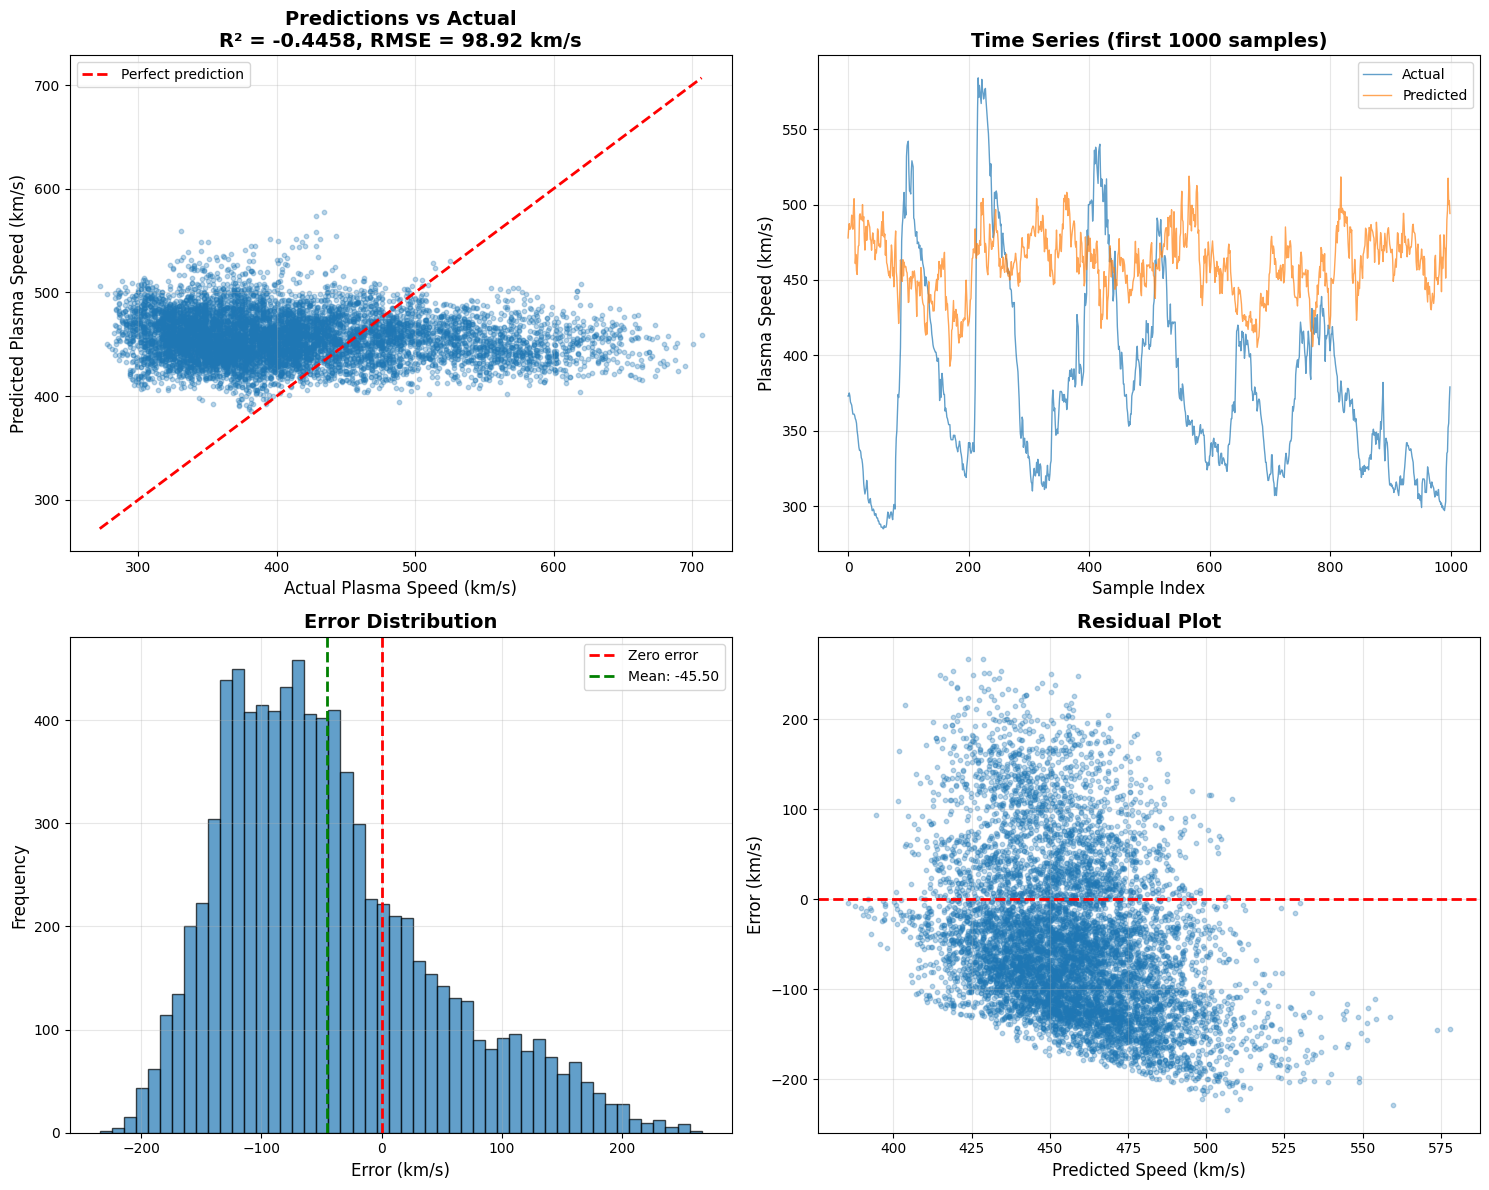


📈 Additional Analysis:

Performance by Speed Range:
  0-300 km/s (183 samples): MAE=173.26 km/s, R²=-1092.7345
  300-400 km/s (4387 samples): MAE=104.42 km/s, R²=-16.3572
  400-500 km/s (2618 samples): MAE=32.73 km/s, R²=-0.9305
  500-1000 km/s (1304 samples): MAE=110.67 km/s, R²=-6.5767

✅ Testing complete!

Files generated:
  - test_results_2018_lead4d_no_norm.csv
  - test_results_2018_lead4d_no_norm.png


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import time

# ============================================
# Configuration
# ============================================
TEST_YEAR = 2018
CACHE_DIR = './cached_data'
CACHE_FILE = os.path.join(CACHE_DIR, 'images_2018.npy')
DELAY_DAYS = 4  # Fixed 4-day lead time

# ============================================
# Model Definition (Must Match Training!)
# ============================================
class SimpleSolarCNN(nn.Module):
    def __init__(self):
        super(SimpleSolarCNN, self).__init__()
        # Conv layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=9, stride=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, stride=2)

        # Batch normalization (after conv3)
        self.bn3 = nn.BatchNorm2d(128)

        # Pooling layers
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # After conv1
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)  # After conv2 (FIXED)
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=1)  # After conv3

        # Fully connected layers
        self.fc1 = nn.Linear(8 * 8 * 128, 4096)
        self.fc2 = nn.Linear(4096, 1)

        # Dropout (after fc1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Conv1 → ReLU → Pool1
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)

        # Conv2 → ReLU → Pool2
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)  # Now uses (3,3) pool, (2,2) stride

        # Conv3 → BatchNorm → ReLU → Pool3
        x = self.conv3(x)
        x = self.bn3(x)    # Added batch normalization
        x = F.relu(x)
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # FC1 → ReLU → Dropout
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)  # Dropout AFTER fc1 activation

        # FC2 (output)
        x = self.fc2(x)

        return x

# ============================================
# Simple Cached Dataset
# ============================================
class SimpleCachedDataset(Dataset):
    def __init__(self, images, speeds):
        """
        images: numpy array of images
        speeds: numpy array of plasma speeds (raw km/s, no normalization)
        """
        self.images = images
        self.speeds = speeds

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.speeds[idx]
        return x[None, :, :].astype(np.float32), np.float32(y)

# ============================================
# Load Everything
# ============================================
print("="*70)
print(f"TESTING ON {TEST_YEAR} DATA WITH {DELAY_DAYS}-DAY FIXED LEAD (NO NORMALIZATION)")
print("="*70)

# 1. Load cached images
print(f"\n📦 Loading cached images from {CACHE_FILE}...")
if not os.path.exists(CACHE_FILE):
    raise FileNotFoundError(f"❌ Cache file not found: {CACHE_FILE}")

cached_images = np.load(CACHE_FILE, mmap_mode='r')
print(f"✅ Loaded {len(cached_images)} images")
print(f"   Image shape: {cached_images.shape}")
print(f"   File size: {os.path.getsize(CACHE_FILE) / 1024**3:.2f} GB")

# 2. Load solar wind data
print(f"\n📊 Loading solar wind data for {TEST_YEAR}...")
df_plasma = pd.read_csv('sws2018.lst.txt',
                        sep=r'\s+',
                        header=None,
                        names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' +
    df_plasma['day'].astype(str) + ' ' +
    df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)

df_plasma.set_index('time', inplace=True)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')

print(f"✅ Loaded {len(df_plasma)} plasma records")
print(f"   Date range: {df_plasma.index.min()} to {df_plasma.index.max()}")
print(f"   Speed range: {df_plasma['plasma_speed'].min():.1f} - {df_plasma['plasma_speed'].max():.1f} km/s")
print(f"   Speed std dev (baseline RMSE): {df_plasma['plasma_speed'].std():.2f} km/s")

# 3. Align images with plasma data (4-day lead time)
print(f"\n🔗 Aligning data with {DELAY_DAYS}-day lead time...")
print("   Note: Image at time T predicts plasma speed at time T+4 days")

# Create timestamps for images (assuming hourly from Jan 1, 2018)
image_start = pd.Timestamp('2018-01-01 00:00:00')
image_times = pd.date_range(start=image_start, periods=len(cached_images), freq='1H')

# Target times are 4 days after image times
lead_time = pd.Timedelta(days=DELAY_DAYS)
target_times = image_times + lead_time

# Find matching plasma data
valid_indices = []
valid_speeds = []
valid_image_times = []
valid_target_times = []

time_window = pd.Timedelta(minutes=30)

for idx, (img_time, target_time) in enumerate(tqdm(
    zip(image_times, target_times),
    total=len(image_times),
    desc="   Aligning",
    ncols=70
)):
    # Find plasma data near target time
    mask = (df_plasma.index >= target_time - time_window) & \
           (df_plasma.index <= target_time + time_window)

    matching = df_plasma[mask]

    if len(matching) > 0:
        # Find closest match
        time_diffs = np.abs((matching.index - target_time).total_seconds())
        closest_idx = np.argmin(time_diffs)
        speed = matching.iloc[closest_idx]['plasma_speed']

        valid_indices.append(idx)
        valid_speeds.append(speed)
        valid_image_times.append(img_time)
        valid_target_times.append(target_time)

print(f"\n✅ Matched {len(valid_indices)} image-speed pairs")
print(f"   Coverage: {len(valid_indices)/len(cached_images)*100:.1f}% of images")
print(f"   Time range: {valid_image_times[0]} to {valid_image_times[-1]}")

# 4. Load checkpoint
print(f"\n🤖 Loading trained model...")
checkpoint_path = "best_model.pt"

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"❌ Checkpoint not found: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

# NO SCALER - model outputs raw km/s values
print(f"✅ Model checkpoint loaded")
print(f"   Epoch: {checkpoint['epoch']+1}")
print(f"   Training val_loss: {checkpoint.get('val_loss', 'N/A'):.2f}")
print(f"   Note: Model trained WITHOUT normalization (raw km/s)")

# 5. Prepare test data
print(f"\n📦 Preparing test dataset...")

# Extract valid images
print("   Extracting valid images...")
test_images = np.zeros((len(valid_indices), cached_images.shape[1], cached_images.shape[2]), dtype=cached_images.dtype)
for i, idx in enumerate(tqdm(valid_indices, desc="   Extracting", ncols=70)):
    test_images[i] = cached_images[idx]

test_speeds = np.array(valid_speeds)

# NO normalization - use raw speeds
print(f"✅ Test data ready")
print(f"   Images: {test_images.shape}")
print(f"   Speed range: {test_speeds.min():.1f} - {test_speeds.max():.1f} km/s")

# 6. Create dataset and dataloader
test_dataset = SimpleCachedDataset(test_images, test_speeds)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(f"   DataLoader created with batch_size=128, num_workers=0")

# 7. Load model and run inference
print(f"\n🚀 Running inference...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Device: {device}")

model = SimpleSolarCNN()
model.load_state_dict(checkpoint['model'])
model.to(device)
model.eval()

# Run inference
all_predictions = []
all_targets = []

start_time = time.time()

print("   Processing batches...")
with torch.no_grad():
    for images, speeds in tqdm(test_loader, desc="   Inference", ncols=70):
        images = images.float().to(device)
        images = torch.log1p(torch.clamp(images, min=250, max=5000))
        speeds = speeds.float().unsqueeze(1).to(device)

        outputs = model(images)

        all_predictions.extend(outputs.cpu().numpy().flatten())
        all_targets.extend(speeds.cpu().numpy().flatten())

inference_time = time.time() - start_time
print(f"\n   ✅ Inference completed in {inference_time:.2f}s")
print(f"   Speed: {len(test_dataset)/inference_time:.1f} samples/sec")

# Convert to arrays (already in km/s - no inverse transform needed!)
predictions = np.array(all_predictions)
targets = np.array(all_targets)

# ============================================
# Compute Metrics
# ============================================
print(f"\n" + "="*70)
print("TEST RESULTS (4-DAY FIXED LEAD - NO NORMALIZATION)")
print("="*70)

mse = mean_squared_error(targets, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets, predictions)
r2 = r2_score(targets, predictions)

print(f"\nTest samples: {len(targets)}")
print(f"Lead time: {DELAY_DAYS} days (fixed)")
print(f"\nMetrics (km/s):")
print(f"  MSE:  {mse:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  R²:   {r2:.4f}")

# Error statistics
errors = targets - predictions
abs_errors = np.abs(errors)

print(f"\nError Statistics:")
print(f"  Mean error:   {errors.mean():.2f} km/s")
print(f"  Std error:    {errors.std():.2f} km/s")
print(f"  Median |error|: {np.median(abs_errors):.2f} km/s")
print(f"  Max |error|:  {abs_errors.max():.2f} km/s")
print(f"  95th percentile |error|: {np.percentile(abs_errors, 95):.2f} km/s")

# Baseline comparison
baseline_predictions = np.full_like(targets, targets.mean())
baseline_mse = mean_squared_error(targets, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(targets, baseline_predictions)

print(f"\n📊 Comparison with Baseline (always predict mean):")
print(f"   Baseline RMSE: {baseline_rmse:.2f} km/s")
print(f"   Model RMSE:    {rmse:.2f} km/s")
print(f"   Improvement:   {baseline_rmse - rmse:.2f} km/s ({(1-mse/baseline_mse)*100:.1f}%)")

print("="*70)

# ============================================
# Save Results
# ============================================
print(f"\n💾 Saving results...")

results_df = pd.DataFrame({
    'image_time': valid_image_times,
    'target_time': valid_target_times,
    'actual_speed': targets,
    'predicted_speed': predictions,
    'error': errors,
    'abs_error': abs_errors,
})

csv_filename = f'test_results_{TEST_YEAR}_lead{DELAY_DAYS}d_no_norm.csv'
results_df.to_csv(csv_filename, index=False)
print(f"✅ Results saved to {csv_filename}")

# ============================================
# Visualizations
# ============================================
print(f"\n📊 Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scatter plot
print("   Creating scatter plot...")
ax = axes[0, 0]
ax.scatter(targets, predictions, alpha=0.3, s=10)
ax.plot([targets.min(), targets.max()],
        [targets.min(), targets.max()],
        'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Plasma Speed (km/s)', fontsize=12)
ax.set_ylabel('Predicted Plasma Speed (km/s)', fontsize=12)
ax.set_title(f'Predictions vs Actual\nR² = {r2:.4f}, RMSE = {rmse:.2f} km/s',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Time series plot
print("   Creating time series plot...")
ax = axes[0, 1]
n_samples = len(targets)
time_indices = range(n_samples)
ax.plot(time_indices, targets[:n_samples], label='Actual', alpha=0.7, linewidth=1)
ax.plot(time_indices, predictions[:n_samples], label='Predicted', alpha=0.7, linewidth=1)
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Plasma Speed (km/s)', fontsize=12)
ax.set_title(f'Time Series (first {n_samples} samples)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Error distribution
print("   Creating error distribution...")
ax = axes[1, 0]
ax.hist(errors, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(errors.mean(), color='g', linestyle='--', linewidth=2,
           label=f'Mean: {errors.mean():.2f}')
ax.set_xlabel('Error (km/s)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Residual plot
print("   Creating residual plot...")
ax = axes[1, 1]
ax.scatter(predictions, errors, alpha=0.3, s=10)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Speed (km/s)', fontsize=12)
ax.set_ylabel('Error (km/s)', fontsize=12)
ax.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_filename = f'test_results_{TEST_YEAR}_lead{DELAY_DAYS}d_no_norm.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"✅ Plot saved to {plot_filename}")
plt.show()

# ============================================
# Additional Analysis
# ============================================
print(f"\n📈 Additional Analysis:")

# Binned performance
print(f"\nPerformance by Speed Range:")
speed_bins = [(0, 300), (300, 400), (400, 500), (500, 1000)]
for low, high in speed_bins:
    mask = (targets >= low) & (targets < high)
    if mask.sum() > 0:
        bin_mae = np.abs(errors[mask]).mean()
        bin_r2 = r2_score(targets[mask], predictions[mask])
        print(f"  {low}-{high} km/s ({mask.sum()} samples): MAE={bin_mae:.2f} km/s, R²={bin_r2:.4f}")

print(f"\n✅ Testing complete!")
print(f"\nFiles generated:")
print(f"  - {csv_filename}")
print(f"  - {plot_filename}")

   Creating scatter plot...
   Creating time series plot...
   Creating error distribution...
   Creating residual plot...
✅ Plot saved to test_results_2018_lead4d_no_norm.png


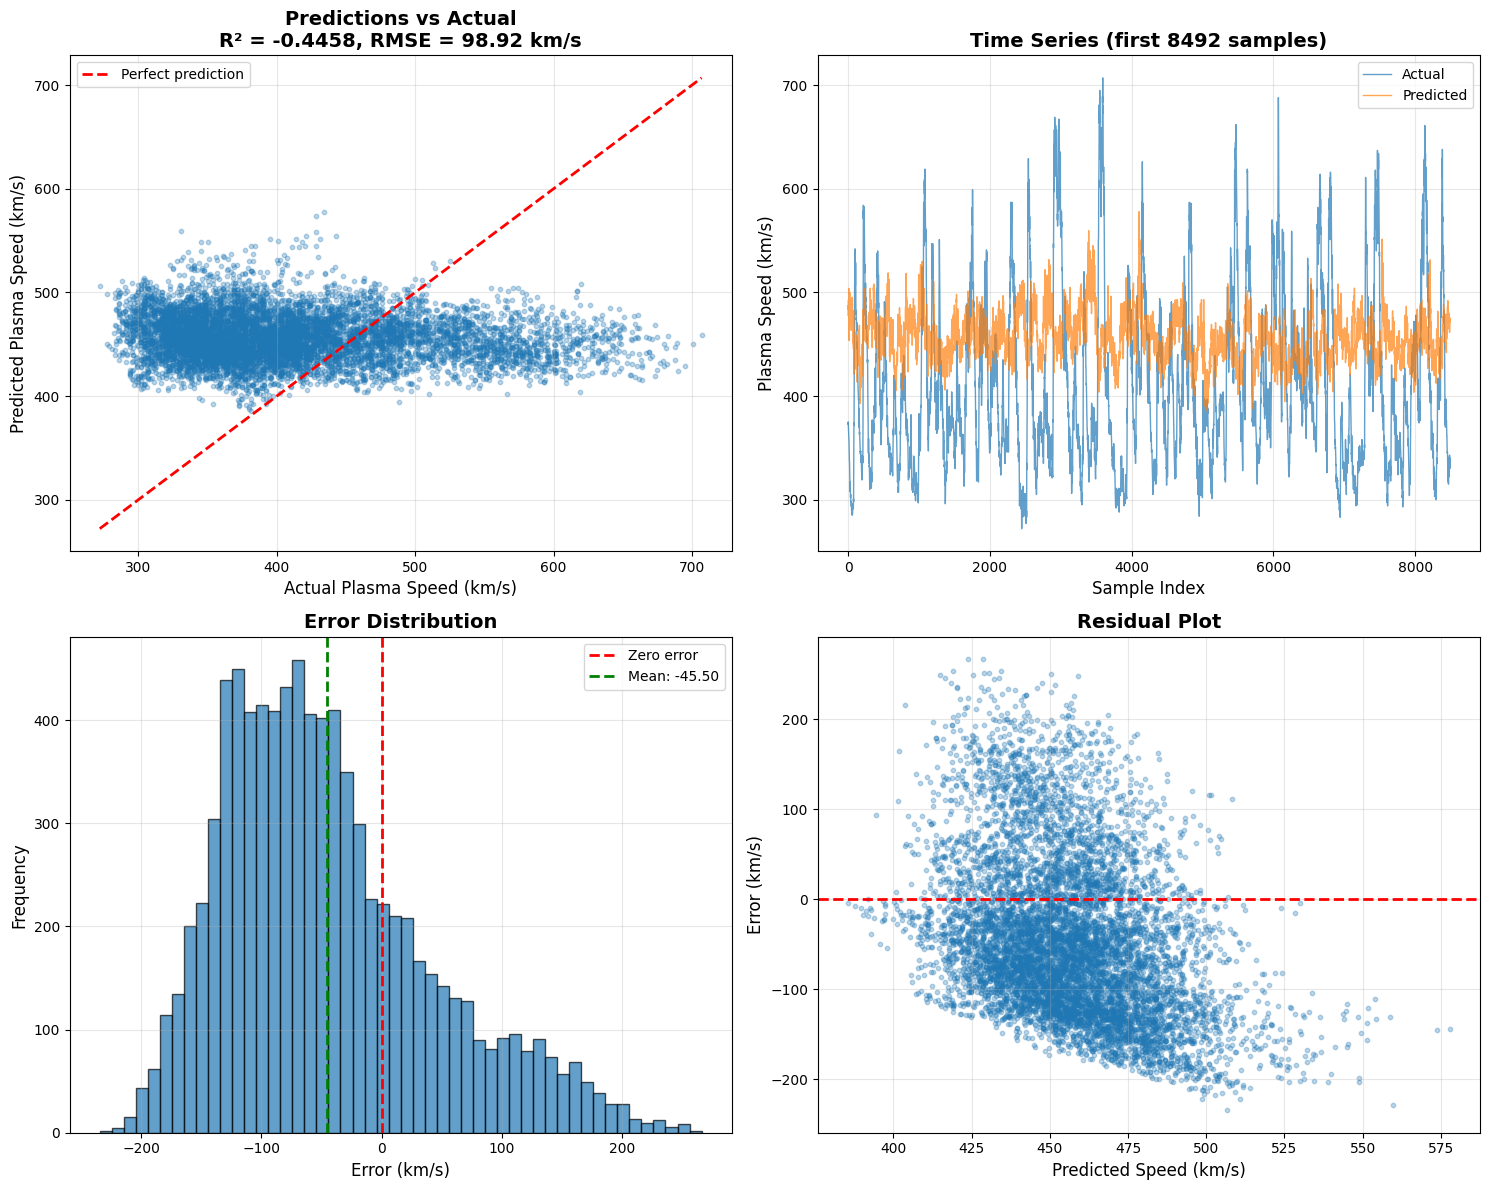


📈 Additional Analysis:

Performance by Speed Range:
  0-300 km/s (183 samples): MAE=173.26 km/s, R²=-1092.7345
  300-400 km/s (4387 samples): MAE=104.42 km/s, R²=-16.3572
  400-500 km/s (2618 samples): MAE=32.73 km/s, R²=-0.9305
  500-1000 km/s (1304 samples): MAE=110.67 km/s, R²=-6.5767

✅ Testing complete!

Files generated:
  - test_results_2018_lead4d_no_norm.csv
  - test_results_2018_lead4d_no_norm.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scatter plot
print("   Creating scatter plot...")
ax = axes[0, 0]
ax.scatter(targets, predictions, alpha=0.3, s=10)
ax.plot([targets.min(), targets.max()],
        [targets.min(), targets.max()],
        'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Plasma Speed (km/s)', fontsize=12)
ax.set_ylabel('Predicted Plasma Speed (km/s)', fontsize=12)
ax.set_title(f'Predictions vs Actual\nR² = {r2:.4f}, RMSE = {rmse:.2f} km/s',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Time series plot
print("   Creating time series plot...")
ax = axes[0, 1]
n_samples = len(targets)
time_indices = range(n_samples)
ax.plot(time_indices, targets[:n_samples], label='Actual', alpha=0.7, linewidth=1)
ax.plot(time_indices, predictions[:n_samples], label='Predicted', alpha=0.7, linewidth=1)
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Plasma Speed (km/s)', fontsize=12)
ax.set_title(f'Time Series (first {n_samples} samples)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Error distribution
print("   Creating error distribution...")
ax = axes[1, 0]
ax.hist(errors, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(errors.mean(), color='g', linestyle='--', linewidth=2,
           label=f'Mean: {errors.mean():.2f}')
ax.set_xlabel('Error (km/s)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Residual plot
print("   Creating residual plot...")
ax = axes[1, 1]
ax.scatter(predictions, errors, alpha=0.3, s=10)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Speed (km/s)', fontsize=12)
ax.set_ylabel('Error (km/s)', fontsize=12)
ax.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_filename = f'test_results_{TEST_YEAR}_lead{DELAY_DAYS}d_no_norm.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"✅ Plot saved to {plot_filename}")
plt.show()

# ============================================
# Additional Analysis
# ============================================
print(f"\n📈 Additional Analysis:")

# Binned performance
print(f"\nPerformance by Speed Range:")
speed_bins = [(0, 300), (300, 400), (400, 500), (500, 1000)]
for low, high in speed_bins:
    mask = (targets >= low) & (targets < high)
    if mask.sum() > 0:
        bin_mae = np.abs(errors[mask]).mean()
        bin_r2 = r2_score(targets[mask], predictions[mask])
        print(f"  {low}-{high} km/s ({mask.sum()} samples): MAE={bin_mae:.2f} km/s, R²={bin_r2:.4f}")

print(f"\n✅ Testing complete!")
print(f"\nFiles generated:")
print(f"  - {csv_filename}")
print(f"  - {plot_filename}")

In [ ]:
# ✅ CORRECT - One-liner
mse = mean_squared_error(
    df_plasma['plasma_speed'],
    np.full(len(df_plasma), df_plasma['plasma_speed'].mean())
)
rmse = np.sqrt(mse)
print(rmse)

82.3090375047396


TESTING ON 2017 DATA WITH TIME-OF-FLIGHT MAPPING (NO NORMALIZATION)

📦 Loading cached images from ./cached_data/images_2017.npy...
✅ Loaded 8455 images
   Image shape: (8455, 512, 512)
   File size: 8.26 GB

📊 Loading solar wind data for 2017...
✅ Loaded 8760 plasma records
   Date range: 2017-01-01 00:00:00 to 2017-12-31 23:00:00
   Speed range: 264.0 - 817.0 km/s
   Speed std dev (baseline RMSE): 109.64 km/s

🤖 Loading trained model...
✅ Model checkpoint loaded
   Epoch: 6
   Training val_loss: 5284.05
   Note: Model trained WITHOUT normalization (raw km/s)
   Device: cuda

🚀 STEP 1: Predicting speeds for all images...


   Predicting:   0%|                           | 0/67 [00:00<?, ?it/s]

✅ Predicted speeds for 8455 images
   Speed range: 324.5 - 710.2 km/s
   Mean speed: 442.3 km/s

⏱️  STEP 2: Calculating time-of-flight...
✅ Calculated time-of-flight
   TOF range: 2.0 - 5.0 days
   Mean TOF: 4.0 days
   Image time range: 2017-01-01 00:00:00 to 2017-12-19 06:00:00
   Target time range: 2017-01-04 11:03:46.093750 to 2017-12-23 16:58:52.937500

🔗 STEP 3: Matching predictions to actual measurements...


/tmp/ipython-input-2500366990.py:192: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  image_times = pd.date_range(start=image_start, periods=len(cached_images), freq='1H')


   Matching:   0%|                           | 0/8455 [00:00<?, ?it/s]


✅ Matched 8455 image-speed pairs
   Coverage: 100.0% of images
   Time range: 2017-01-01 00:00:00 to 2017-12-19 06:00:00

TEST RESULTS (TIME-OF-FLIGHT MAPPING - NO NORMALIZATION)

Test samples: 8455
Mapping method: Time-of-flight (1 AU / predicted_speed)

Time-of-Flight Statistics:
  Mean TOF: 4.01 days
  Median TOF: 4.07 days
  TOF range: 2.44 - 5.34 days

Metrics (km/s):
  MSE:  12106.12
  RMSE: 110.03
  MAE:  86.68
  R²:   -0.0320

Error Statistics:
  Mean error:   4.51 km/s
  Std error:    109.94 km/s
  Median |error|: 70.71 km/s
  Max |error|:  354.39 km/s
  95th percentile |error|: 217.08 km/s

📊 Comparison with Baseline (always predict mean):
   Baseline RMSE: 108.31 km/s
   Model RMSE:    110.03 km/s
   Improvement:   -1.72 km/s (-3.2%)

💾 Saving results...
✅ Results saved to test_results_2017_tof_no_norm.csv

📊 Creating visualizations...
   Creating scatter plot...
   Creating time series plot...
   Creating error distribution...
   Creating residual plot...
   Creating TOF d

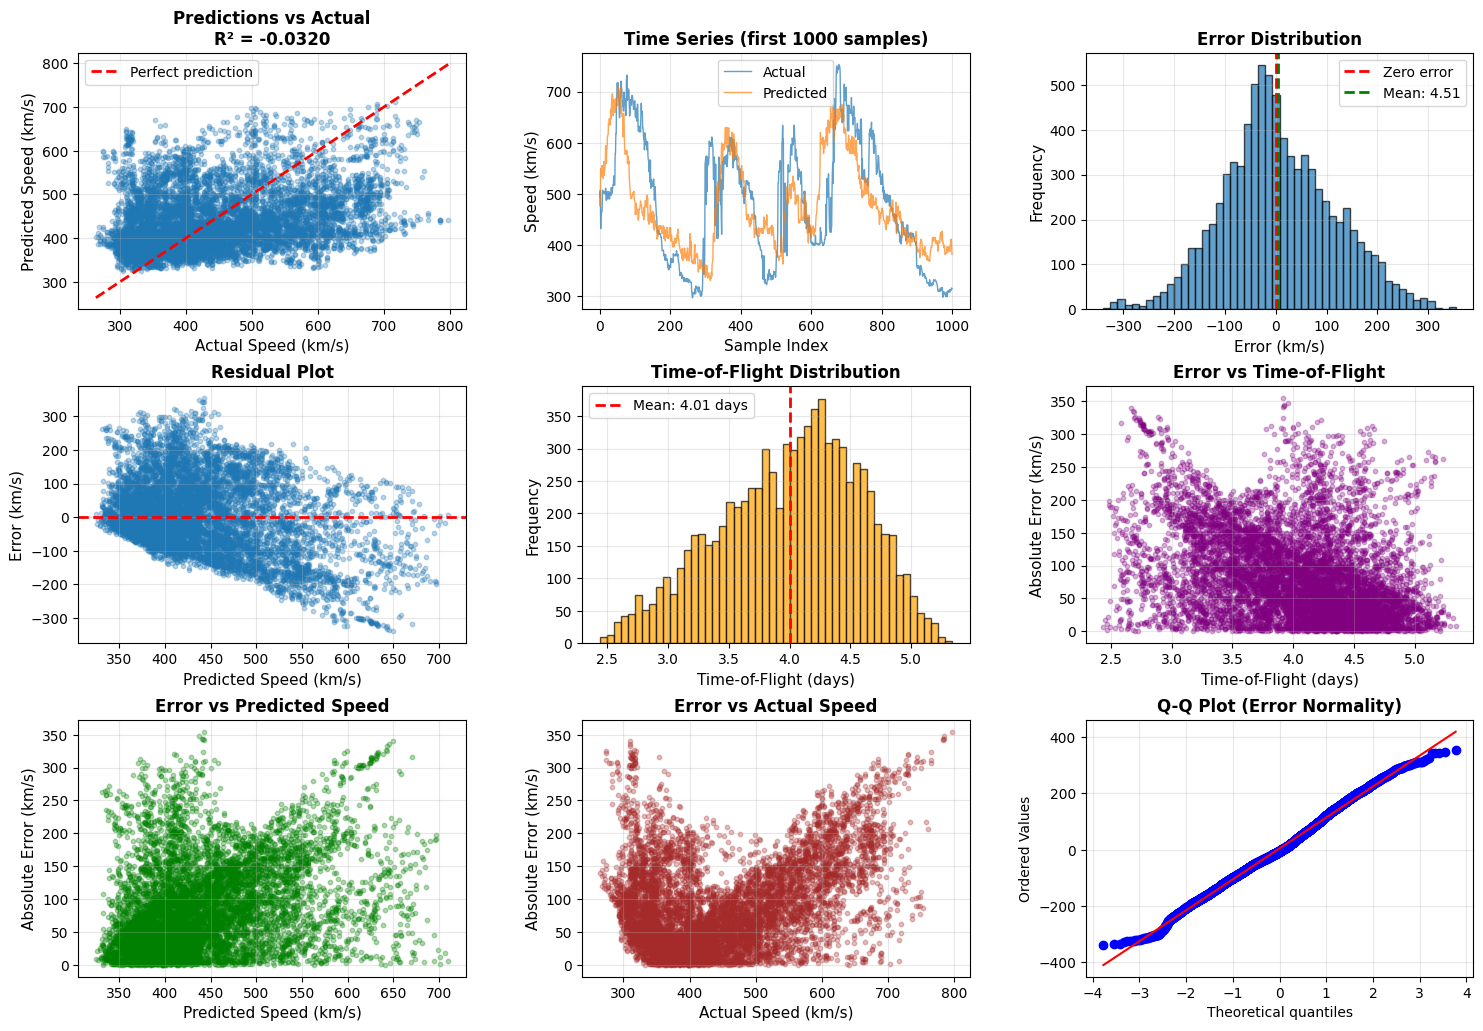


📈 Additional Analysis:

Performance by Speed Range:
  0-300 km/s (163 samples): MAE=134.65 km/s, R²=-303.0662, Mean TOF=4.16 days
  300-400 km/s (3468 samples): MAE=74.44 km/s, R²=-11.9738, Mean TOF=4.17 days
  400-500 km/s (2294 samples): MAE=55.43 km/s, R²=-4.4293, Mean TOF=4.02 days
  500-1000 km/s (2530 samples): MAE=128.70 km/s, R²=-4.6469, Mean TOF=3.76 days

Performance by TOF Range:
  0-3 days (484 samples): MAE=137.70 km/s, R²=-0.5902
  3-4 days (3381 samples): MAE=101.02 km/s, R²=-0.1210
  4-5 days (4401 samples): MAE=71.45 km/s, R²=-0.0330
  5-10 days (189 samples): MAE=53.86 km/s, R²=-0.2588

✅ Testing complete!

Files generated:
  - test_results_2017_tof_no_norm.csv
  - test_results_2017_tof_no_norm.png


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import time

# ============================================
# Configuration
# ============================================
TEST_YEAR = 2017
CACHE_DIR = './cached_data'
CACHE_FILE = os.path.join(CACHE_DIR, 'images_2017.npy')
AU_KM = 149_597_870.7  # 1 AU in kilometers

# ============================================
# Model Definition (Must Match Training!)
# ============================================
class SimpleSolarCNN(nn.Module):
    def __init__(self):
        super(SimpleSolarCNN, self).__init__()
        # Conv layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=9, stride=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, stride=2)

        # Batch normalization (after conv3)
        self.bn3 = nn.BatchNorm2d(128)

        # Pooling layers
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # After conv1
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)  # After conv2
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=1)  # After conv3

        # Fully connected layers
        self.fc1 = nn.Linear(8 * 8 * 128, 4096)
        self.fc2 = nn.Linear(4096, 1)

        # Dropout (after fc1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Conv1 → ReLU → Pool1
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)

        # Conv2 → ReLU → Pool2
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)

        # Conv3 → BatchNorm → ReLU → Pool3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # FC1 → ReLU → Dropout
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # FC2 (output)
        x = self.fc2(x)

        return x

# ============================================
# Simple Dataset for Initial Prediction
# ============================================
class SimpleImageDataset(Dataset):
    def __init__(self, images):
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx]
        return x[None, :, :].astype(np.float32)

# ============================================
# Load Everything
# ============================================
print("="*70)
print(f"TESTING ON {TEST_YEAR} DATA WITH TIME-OF-FLIGHT MAPPING (NO NORMALIZATION)")
print("="*70)

# 1. Load cached images
print(f"\n📦 Loading cached images from {CACHE_FILE}...")
if not os.path.exists(CACHE_FILE):
    raise FileNotFoundError(f"❌ Cache file not found: {CACHE_FILE}")

cached_images = np.load(CACHE_FILE, mmap_mode='r')
print(f"✅ Loaded {len(cached_images)} images")
print(f"   Image shape: {cached_images.shape}")
print(f"   File size: {os.path.getsize(CACHE_FILE) / 1024**3:.2f} GB")

# 2. Load solar wind data
print(f"\n📊 Loading solar wind data for {TEST_YEAR}...")
df_plasma = pd.read_csv('sws2017.lst',
                        sep=r'\s+',
                        header=None,
                        names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' +
    df_plasma['day'].astype(str) + ' ' +
    df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)

df_plasma.set_index('time', inplace=True)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')

print(f"✅ Loaded {len(df_plasma)} plasma records")
print(f"   Date range: {df_plasma.index.min()} to {df_plasma.index.max()}")
print(f"   Speed range: {df_plasma['plasma_speed'].min():.1f} - {df_plasma['plasma_speed'].max():.1f} km/s")
print(f"   Speed std dev (baseline RMSE): {df_plasma['plasma_speed'].std():.2f} km/s")

# 3. Load model checkpoint
print(f"\n🤖 Loading trained model...")
checkpoint_path = "best_model.pt"

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"❌ Checkpoint not found: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

print(f"✅ Model checkpoint loaded")
print(f"   Epoch: {checkpoint['epoch']+1}")
print(f"   Training val_loss: {checkpoint.get('val_loss', 'N/A'):.2f}")
print(f"   Note: Model trained WITHOUT normalization (raw km/s)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Device: {device}")

model = SimpleSolarCNN()
model.load_state_dict(checkpoint['model'])
model.to(device)
model.eval()

# ============================================
# STEP 1: Predict speeds for all images
# ============================================
print(f"\n🚀 STEP 1: Predicting speeds for all images...")

# Create dataset for all images
all_images_dataset = SimpleImageDataset(cached_images)
all_images_loader = DataLoader(
    all_images_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

# Predict speeds (already in km/s - no normalization!)
predicted_speeds = []

with torch.no_grad():
    for images in tqdm(all_images_loader, desc="   Predicting", ncols=70):
        images = images.float().to(device)
        images = torch.log1p(torch.clamp(images, min=250, max=5000))

        outputs = model(images)
        predicted_speeds.extend(outputs.cpu().numpy().flatten())

predicted_speeds = np.array(predicted_speeds)

print(f"✅ Predicted speeds for {len(predicted_speeds)} images")
print(f"   Speed range: {predicted_speeds.min():.1f} - {predicted_speeds.max():.1f} km/s")
print(f"   Mean speed: {predicted_speeds.mean():.1f} km/s")

# ============================================
# STEP 2: Calculate time-of-flight for each image
# ============================================
print(f"\n⏱️  STEP 2: Calculating time-of-flight...")

# Create timestamps for images (assuming hourly from Jan 1, 2018)
image_start = pd.Timestamp('2017-01-01 00:00:00')
image_times = pd.date_range(start=image_start, periods=len(cached_images), freq='1H')

# Calculate TOF: distance / speed
# Clamp predictions to reasonable range to avoid extreme TOF values
predicted_speeds_clamped = np.clip(predicted_speeds, 250, 1000)  # Typical range
tof_seconds = AU_KM / predicted_speeds_clamped
tof_timedelta = pd.to_timedelta(tof_seconds, unit='s')

# Target time = image time + TOF
target_times = image_times + tof_timedelta

print(f"✅ Calculated time-of-flight")
print(f"   TOF range: {tof_timedelta.min().days:.1f} - {tof_timedelta.max().days:.1f} days")
print(f"   Mean TOF: {tof_timedelta.mean().days:.1f} days")
print(f"   Image time range: {image_times[0]} to {image_times[-1]}")
print(f"   Target time range: {target_times[0]} to {target_times[-1]}")

# ============================================
# STEP 3: Match predictions to actual measurements
# ============================================
print(f"\n🔗 STEP 3: Matching predictions to actual measurements...")

valid_indices = []
actual_speeds = []
predicted_speeds_matched = []
tof_days_matched = []
valid_image_times = []
valid_target_times = []

time_window = pd.Timedelta(minutes=30)

for idx, (img_time, target_time, pred_speed, tof) in enumerate(tqdm(
    zip(image_times, target_times, predicted_speeds, tof_timedelta),
    total=len(image_times),
    desc="   Matching",
    ncols=70
)):
    # Find plasma data near target time
    mask = (df_plasma.index >= target_time - time_window) & \
           (df_plasma.index <= target_time + time_window)

    matching = df_plasma[mask]

    if len(matching) > 0:
        # Find closest match
        time_diffs = np.abs((matching.index - target_time).total_seconds())
        closest_idx = np.argmin(time_diffs)
        actual_speed = matching.iloc[closest_idx]['plasma_speed']

        valid_indices.append(idx)
        actual_speeds.append(actual_speed)
        predicted_speeds_matched.append(pred_speed)
        tof_days_matched.append(tof.total_seconds() / 86400)
        valid_image_times.append(img_time)
        valid_target_times.append(target_time)

# Convert to arrays
actual_speeds = np.array(actual_speeds)
predicted_speeds_matched = np.array(predicted_speeds_matched)
tof_days_matched = np.array(tof_days_matched)

print(f"\n✅ Matched {len(valid_indices)} image-speed pairs")
print(f"   Coverage: {len(valid_indices)/len(cached_images)*100:.1f}% of images")
print(f"   Time range: {valid_image_times[0]} to {valid_image_times[-1]}")

# ============================================
# STEP 4: Compute Metrics
# ============================================
print(f"\n" + "="*70)
print("TEST RESULTS (TIME-OF-FLIGHT MAPPING - NO NORMALIZATION)")
print("="*70)

mse = mean_squared_error(actual_speeds, predicted_speeds_matched)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_speeds, predicted_speeds_matched)
r2 = r2_score(actual_speeds, predicted_speeds_matched)

print(f"\nTest samples: {len(actual_speeds)}")
print(f"Mapping method: Time-of-flight (1 AU / predicted_speed)")
print(f"\nTime-of-Flight Statistics:")
print(f"  Mean TOF: {np.mean(tof_days_matched):.2f} days")
print(f"  Median TOF: {np.median(tof_days_matched):.2f} days")
print(f"  TOF range: {np.min(tof_days_matched):.2f} - {np.max(tof_days_matched):.2f} days")

print(f"\nMetrics (km/s):")
print(f"  MSE:  {mse:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  R²:   {r2:.4f}")

# Error statistics
errors = actual_speeds - predicted_speeds_matched
abs_errors = np.abs(errors)

print(f"\nError Statistics:")
print(f"  Mean error:   {errors.mean():.2f} km/s")
print(f"  Std error:    {errors.std():.2f} km/s")
print(f"  Median |error|: {np.median(abs_errors):.2f} km/s")
print(f"  Max |error|:  {abs_errors.max():.2f} km/s")
print(f"  95th percentile |error|: {np.percentile(abs_errors, 95):.2f} km/s")

# Baseline comparison
baseline_predictions = np.full_like(actual_speeds, actual_speeds.mean())
baseline_mse = mean_squared_error(actual_speeds, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(actual_speeds, baseline_predictions)

print(f"\n📊 Comparison with Baseline (always predict mean):")
print(f"   Baseline RMSE: {baseline_rmse:.2f} km/s")
print(f"   Model RMSE:    {rmse:.2f} km/s")
print(f"   Improvement:   {baseline_rmse - rmse:.2f} km/s ({(1-mse/baseline_mse)*100:.1f}%)")

print("="*70)

# ============================================
# STEP 5: Save Results
# ============================================
print(f"\n💾 Saving results...")

results_df = pd.DataFrame({
    'image_time': valid_image_times,
    'target_time': valid_target_times,
    'tof_days': tof_days_matched,
    'predicted_speed': predicted_speeds_matched,
    'actual_speed': actual_speeds,
    'error': errors,
    'abs_error': abs_errors,
})

csv_filename = f'test_results_{TEST_YEAR}_tof_no_norm.csv'
results_df.to_csv(csv_filename, index=False)
print(f"✅ Results saved to {csv_filename}")

# ============================================
# STEP 6: Visualizations
# ============================================
print(f"\n📊 Creating visualizations...")

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Scatter plot (predictions vs actual)
print("   Creating scatter plot...")
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(actual_speeds, predicted_speeds_matched, alpha=0.3, s=10)
ax1.plot([actual_speeds.min(), actual_speeds.max()],
         [actual_speeds.min(), actual_speeds.max()],
         'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual Speed (km/s)', fontsize=11)
ax1.set_ylabel('Predicted Speed (km/s)', fontsize=11)
ax1.set_title(f'Predictions vs Actual\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Time series
print("   Creating time series plot...")
ax2 = fig.add_subplot(gs[0, 1])
n_samples = min(1000, len(actual_speeds))
time_indices = range(n_samples)
ax2.plot(time_indices, actual_speeds[:n_samples], label='Actual', alpha=0.7, linewidth=1)
ax2.plot(time_indices, predicted_speeds_matched[:n_samples], label='Predicted', alpha=0.7, linewidth=1)
ax2.set_xlabel('Sample Index', fontsize=11)
ax2.set_ylabel('Speed (km/s)', fontsize=11)
ax2.set_title(f'Time Series (first {n_samples} samples)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Error distribution
print("   Creating error distribution...")
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(errors, bins=50, alpha=0.7, edgecolor='black')
ax3.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero error')
ax3.axvline(errors.mean(), color='g', linestyle='--', linewidth=2, label=f'Mean: {errors.mean():.2f}')
ax3.set_xlabel('Error (km/s)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Residual plot
print("   Creating residual plot...")
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(predicted_speeds_matched, errors, alpha=0.3, s=10)
ax4.axhline(0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Predicted Speed (km/s)', fontsize=11)
ax4.set_ylabel('Error (km/s)', fontsize=11)
ax4.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. TOF distribution
print("   Creating TOF distribution...")
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(tof_days_matched, bins=50, alpha=0.7, edgecolor='black', color='orange')
ax5.axvline(np.mean(tof_days_matched), color='r', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(tof_days_matched):.2f} days')
ax5.set_xlabel('Time-of-Flight (days)', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title('Time-of-Flight Distribution', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Error vs TOF
print("   Creating error vs TOF plot...")
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(tof_days_matched, abs_errors, alpha=0.3, s=10, color='purple')
ax6.set_xlabel('Time-of-Flight (days)', fontsize=11)
ax6.set_ylabel('Absolute Error (km/s)', fontsize=11)
ax6.set_title('Error vs Time-of-Flight', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

# 7. Error vs Predicted Speed
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(predicted_speeds_matched, abs_errors, alpha=0.3, s=10, color='green')
ax7.set_xlabel('Predicted Speed (km/s)', fontsize=11)
ax7.set_ylabel('Absolute Error (km/s)', fontsize=11)
ax7.set_title('Error vs Predicted Speed', fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8. Error vs Actual Speed
ax8 = fig.add_subplot(gs[2, 1])
ax8.scatter(actual_speeds, abs_errors, alpha=0.3, s=10, color='brown')
ax8.set_xlabel('Actual Speed (km/s)', fontsize=11)
ax8.set_ylabel('Absolute Error (km/s)', fontsize=11)
ax8.set_title('Error vs Actual Speed', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3)

# 9. Q-Q plot
ax9 = fig.add_subplot(gs[2, 2])
from scipy import stats
stats.probplot(errors, dist="norm", plot=ax9)
ax9.set_title('Q-Q Plot (Error Normality)', fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3)

plot_filename = f'test_results_{TEST_YEAR}_tof_no_norm.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"✅ Plot saved to {plot_filename}")
plt.show()

# ============================================
# Additional Analysis
# ============================================
print(f"\n📈 Additional Analysis:")

# Performance by speed range
print(f"\nPerformance by Speed Range:")
speed_bins = [(0, 300), (300, 400), (400, 500), (500, 1000)]
for low, high in speed_bins:
    mask = (actual_speeds >= low) & (actual_speeds < high)
    if mask.sum() > 0:
        bin_mae = abs_errors[mask].mean()
        bin_r2 = r2_score(actual_speeds[mask], predicted_speeds_matched[mask])
        bin_tof = np.mean(tof_days_matched[mask])
        print(f"  {low}-{high} km/s ({mask.sum()} samples): MAE={bin_mae:.2f} km/s, R²={bin_r2:.4f}, Mean TOF={bin_tof:.2f} days")

# Performance by TOF range
print(f"\nPerformance by TOF Range:")
tof_bins = [(0, 3), (3, 4), (4, 5), (5, 10)]
for low, high in tof_bins:
    mask = (tof_days_matched >= low) & (tof_days_matched < high)
    if mask.sum() > 0:
        bin_mae = abs_errors[mask].mean()
        bin_r2 = r2_score(actual_speeds[mask], predicted_speeds_matched[mask])
        print(f"  {low}-{high} days ({mask.sum()} samples): MAE={bin_mae:.2f} km/s, R²={bin_r2:.4f}")

print(f"\n✅ Testing complete!")
print(f"\nFiles generated:")
print(f"  - {csv_filename}")
print(f"  - {plot_filename}")

TESTING ON 2018 DATA WITH GROUND TRUTH TOF MAPPING

📦 Loading cached images from ./cached_data/images_2018.npy...
✅ Loaded 8492 images
   Image shape: (8492, 512, 512)
   File size: 8.29 GB

📊 Loading solar wind data for 2018...
✅ Loaded 8760 plasma records
   Date range: 2018-01-01 00:00:00 to 2018-12-31 23:00:00
   Speed range: 272.0 - 707.0 km/s
   Speed std dev (baseline RMSE): 82.31 km/s

⏱️  STEP 1: Calculating time-of-flight using GROUND TRUTH speeds...
   Computing TOF using ground truth speeds...


/tmp/ipython-input-2278310665.py:138: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  image_times = pd.date_range(start=image_start, periods=len(cached_images), freq='1H')


   Processing:   0%|                         | 0/8492 [00:00<?, ?it/s]


✅ Matched 4476 image-speed pairs using ground truth TOF
   Coverage: 52.7% of images
   Time range: 2018-01-01 00:00:00 to 2018-12-20 17:00:00

   Ground Truth TOF Statistics:
   Mean TOF: 4.37 days
   Median TOF: 4.43 days
   TOF range: 2.51 - 6.25 days

🤖 STEP 2: Loading trained model and predicting speeds...
✅ Model checkpoint loaded
   Epoch: 6
   Training val_loss: 5284.05
   Device: cuda

   Extracting valid images for prediction...


   Extracting:   0%|                         | 0/4476 [00:00<?, ?it/s]


   Running inference...


   Predicting:   0%|                           | 0/35 [00:00<?, ?it/s]


✅ Predictions complete
   Predicted speed range: 322.4 - 692.2 km/s
   Predicted speed mean: 428.6 km/s

TEST RESULTS (GROUND TRUTH TOF MAPPING)

Test samples: 4476
Mapping method: Ground truth TOF (1 AU / actual_speed)

Metrics (km/s):
  MSE:  9320.60
  RMSE: 96.54
  MAE:  77.50
  R²:   -0.3442

Error Statistics:
  Mean error:   -17.76 km/s
  Std error:    94.90 km/s
  Median |error|: 66.19 km/s
  Max |error|:  295.91 km/s
  95th percentile |error|: 193.85 km/s

📊 Comparison with Baseline (always predict mean):
   Baseline RMSE: 83.27 km/s
   Model RMSE:    96.54 km/s
   Improvement:   -13.27 km/s (-34.4%)

💾 Saving results...
✅ Results saved to test_results_2018_ground_truth_tof.csv

📊 Creating visualizations...
   Creating scatter plot...
   Creating time series plot...
   Creating error distribution...
   Creating residual plot...
   Creating TOF distribution...
   Creating error vs TOF plot...
✅ Plot saved to test_results_2018_ground_truth_tof.png


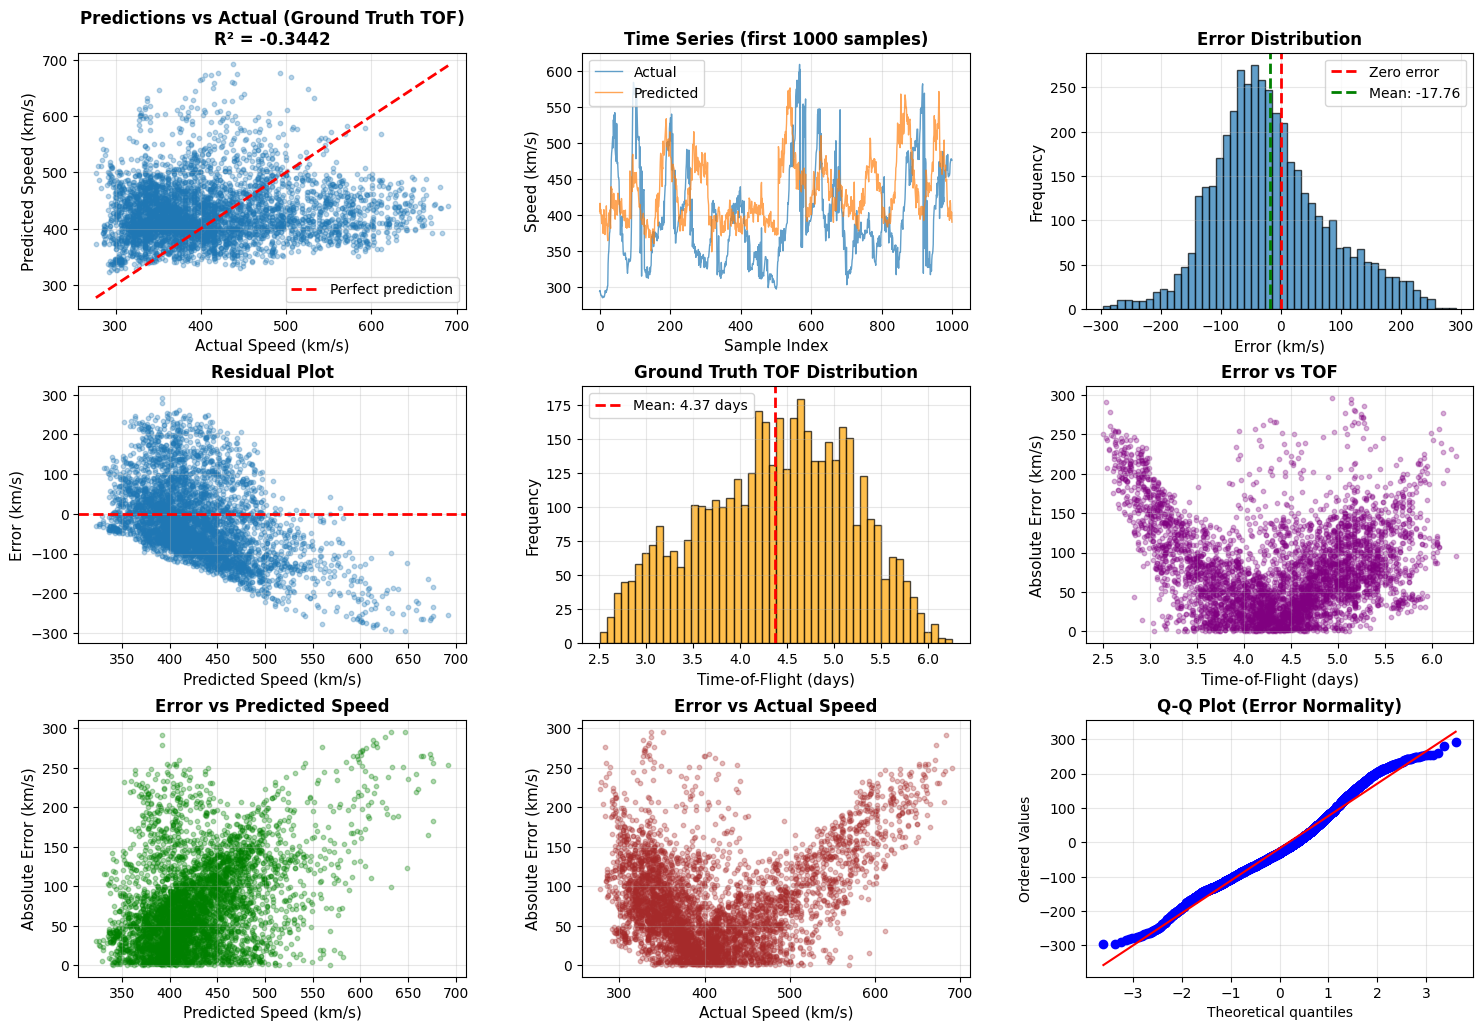


📈 Additional Analysis:

Performance by Speed Range:
  0-300 km/s (97 samples): MAE=131.96 km/s, R²=-727.6741, Mean TOF=5.92 days
  300-400 km/s (2328 samples): MAE=74.56 km/s, R²=-10.5153, Mean TOF=4.94 days
  400-500 km/s (1356 samples): MAE=48.78 km/s, R²=-3.9382, Mean TOF=3.95 days
  500-1000 km/s (695 samples): MAE=135.77 km/s, R²=-10.1058, Mean TOF=3.09 days

Performance by TOF Range:
  0-3 days (249 samples): MAE=187.88 km/s, R²=-48.7426
  3-4 days (1187 samples): MAE=73.63 km/s, R²=-3.5355
  4-5 days (1931 samples): MAE=53.29 km/s, R²=-7.7609
  5-10 days (1109 samples): MAE=99.01 km/s, R²=-48.9567

✅ Testing complete!

Files generated:
  - test_results_2018_ground_truth_tof.csv
  - test_results_2018_ground_truth_tof.png


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import time

# ============================================
# Configuration
# ============================================
TEST_YEAR = 2018
CACHE_DIR = './cached_data'
CACHE_FILE = os.path.join(CACHE_DIR, 'images_2018.npy')
AU_KM = 149_597_870.7  # 1 AU in kilometers

# ============================================
# Model Definition (Must Match Training!)
# ============================================
class SimpleSolarCNN(nn.Module):
    def __init__(self):
        super(SimpleSolarCNN, self).__init__()
        # Conv layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=9, stride=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, stride=2)

        # Batch normalization (after conv3)
        self.bn3 = nn.BatchNorm2d(128)

        # Pooling layers
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # After conv1
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)  # After conv2
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=1)  # After conv3

        # Fully connected layers
        self.fc1 = nn.Linear(8 * 8 * 128, 4096)
        self.fc2 = nn.Linear(4096, 1)

        # Dropout (after fc1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Conv1 → ReLU → Pool1
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)

        # Conv2 → ReLU → Pool2
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)

        # Conv3 → BatchNorm → ReLU → Pool3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # FC1 → ReLU → Dropout
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # FC2 (output)
        x = self.fc2(x)

        return x

# ============================================
# Simple Dataset for Initial Prediction
# ============================================
class SimpleImageDataset(Dataset):
    def __init__(self, images):
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx]
        return x[None, :, :].astype(np.float32)

# ============================================
# Load Everything
# ============================================
print("="*70)
print(f"TESTING ON {TEST_YEAR} DATA WITH GROUND TRUTH TOF MAPPING")
print("="*70)

# 1. Load cached images
print(f"\n📦 Loading cached images from {CACHE_FILE}...")
if not os.path.exists(CACHE_FILE):
    raise FileNotFoundError(f"❌ Cache file not found: {CACHE_FILE}")

cached_images = np.load(CACHE_FILE, mmap_mode='r')
print(f"✅ Loaded {len(cached_images)} images")
print(f"   Image shape: {cached_images.shape}")
print(f"   File size: {os.path.getsize(CACHE_FILE) / 1024**3:.2f} GB")

# 2. Load solar wind data
print(f"\n📊 Loading solar wind data for {TEST_YEAR}...")
df_plasma = pd.read_csv('sws2018.lst.txt',
                        sep=r'\s+',
                        header=None,
                        names=['year', 'day', 'hour', 'plasma_speed'])

df_plasma['time'] = pd.to_datetime(
    df_plasma['year'].astype(str) + '-' +
    df_plasma['day'].astype(str) + ' ' +
    df_plasma['hour'].astype(str) + ':00:00',
    format='%Y-%j %H:%M:%S'
)

df_plasma.set_index('time', inplace=True)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].replace(9999.0, np.nan)
df_plasma['plasma_speed'] = df_plasma['plasma_speed'].interpolate(method='linear')

print(f"✅ Loaded {len(df_plasma)} plasma records")
print(f"   Date range: {df_plasma.index.min()} to {df_plasma.index.max()}")
print(f"   Speed range: {df_plasma['plasma_speed'].min():.1f} - {df_plasma['plasma_speed'].max():.1f} km/s")
print(f"   Speed std dev (baseline RMSE): {df_plasma['plasma_speed'].std():.2f} km/s")

# ============================================
# STEP 1: Calculate TOF using GROUND TRUTH speeds
# ============================================
print(f"\n⏱️  STEP 1: Calculating time-of-flight using GROUND TRUTH speeds...")

# Create timestamps for images (assuming hourly from Jan 1, 2018)
image_start = pd.Timestamp('2018-01-01 00:00:00')
image_times = pd.date_range(start=image_start, periods=len(cached_images), freq='1H')

# For each image time, calculate TOF using the actual speed at arrival
# We need to iterate to find the right mapping
valid_indices = []
actual_speeds = []
tof_days_matched = []
valid_image_times = []
valid_target_times = []

time_window = pd.Timedelta(minutes=30)

print("   Computing TOF using ground truth speeds...")
for idx, img_time in enumerate(tqdm(image_times, desc="   Processing", ncols=70)):
    # Get plasma data for potential arrival times (between 2-10 days ahead)
    min_arrival = img_time + pd.Timedelta(days=2)
    max_arrival = img_time + pd.Timedelta(days=10)

    mask = (df_plasma.index >= min_arrival) & (df_plasma.index <= max_arrival)
    potential_arrivals = df_plasma[mask]

    if len(potential_arrivals) == 0:
        continue

    # For each potential arrival, calculate what the TOF would be
    best_match_idx = None
    best_time_diff = None

    for plasma_idx, (plasma_time, plasma_row) in enumerate(potential_arrivals.iterrows()):
        speed = plasma_row['plasma_speed']

        # Calculate expected TOF based on this speed
        expected_tof_seconds = AU_KM / speed
        expected_arrival = img_time + pd.Timedelta(seconds=expected_tof_seconds)

        # How close is the expected arrival to the actual plasma time?
        time_diff = abs((plasma_time - expected_arrival).total_seconds())

        if best_time_diff is None or time_diff < best_time_diff:
            best_time_diff = time_diff
            best_match_idx = plasma_idx
            best_match_time = plasma_time
            best_match_speed = speed
            best_tof = expected_tof_seconds

    # Only keep matches within tolerance
    if best_time_diff is not None and best_time_diff < 1800:  # 30 minutes
        valid_indices.append(idx)
        actual_speeds.append(best_match_speed)
        tof_days_matched.append(best_tof / 86400)
        valid_image_times.append(img_time)
        valid_target_times.append(best_match_time)

actual_speeds = np.array(actual_speeds)
tof_days_matched = np.array(tof_days_matched)

print(f"\n✅ Matched {len(valid_indices)} image-speed pairs using ground truth TOF")
print(f"   Coverage: {len(valid_indices)/len(cached_images)*100:.1f}% of images")
print(f"   Time range: {valid_image_times[0]} to {valid_image_times[-1]}")
print(f"\n   Ground Truth TOF Statistics:")
print(f"   Mean TOF: {np.mean(tof_days_matched):.2f} days")
print(f"   Median TOF: {np.median(tof_days_matched):.2f} days")
print(f"   TOF range: {np.min(tof_days_matched):.2f} - {np.max(tof_days_matched):.2f} days")

# ============================================
# STEP 2: Load model and predict speeds
# ============================================
print(f"\n🤖 STEP 2: Loading trained model and predicting speeds...")

checkpoint_path = "best_model.pt"
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"❌ Checkpoint not found: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

print(f"✅ Model checkpoint loaded")
print(f"   Epoch: {checkpoint['epoch']+1}")
print(f"   Training val_loss: {checkpoint.get('val_loss', 'N/A'):.2f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Device: {device}")

model = SimpleSolarCNN()
model.load_state_dict(checkpoint['model'])
model.to(device)
model.eval()

# Extract valid images
print("\n   Extracting valid images for prediction...")
test_images = np.zeros((len(valid_indices), cached_images.shape[1], cached_images.shape[2]),
                        dtype=cached_images.dtype)
for i, idx in enumerate(tqdm(valid_indices, desc="   Extracting", ncols=70)):
    test_images[i] = cached_images[idx]

# Predict speeds
print("\n   Running inference...")
test_dataset = SimpleImageDataset(test_images)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

predicted_speeds = []
with torch.no_grad():
    for images in tqdm(test_loader, desc="   Predicting", ncols=70):
        images = images.float().to(device)
        images = torch.log1p(torch.clamp(images, min=250, max=5000))
        outputs = model(images)
        predicted_speeds.extend(outputs.cpu().numpy().flatten())

predicted_speeds = np.array(predicted_speeds)

print(f"\n✅ Predictions complete")
print(f"   Predicted speed range: {predicted_speeds.min():.1f} - {predicted_speeds.max():.1f} km/s")
print(f"   Predicted speed mean: {predicted_speeds.mean():.1f} km/s")

# ============================================
# STEP 3: Compute Metrics
# ============================================
print(f"\n" + "="*70)
print("TEST RESULTS (GROUND TRUTH TOF MAPPING)")
print("="*70)

mse = mean_squared_error(actual_speeds, predicted_speeds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_speeds, predicted_speeds)
r2 = r2_score(actual_speeds, predicted_speeds)

print(f"\nTest samples: {len(actual_speeds)}")
print(f"Mapping method: Ground truth TOF (1 AU / actual_speed)")

print(f"\nMetrics (km/s):")
print(f"  MSE:  {mse:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  R²:   {r2:.4f}")

# Error statistics
errors = actual_speeds - predicted_speeds
abs_errors = np.abs(errors)

print(f"\nError Statistics:")
print(f"  Mean error:   {errors.mean():.2f} km/s")
print(f"  Std error:    {errors.std():.2f} km/s")
print(f"  Median |error|: {np.median(abs_errors):.2f} km/s")
print(f"  Max |error|:  {abs_errors.max():.2f} km/s")
print(f"  95th percentile |error|: {np.percentile(abs_errors, 95):.2f} km/s")

# Baseline comparison
baseline_predictions = np.full_like(actual_speeds, actual_speeds.mean())
baseline_mse = mean_squared_error(actual_speeds, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)

print(f"\n📊 Comparison with Baseline (always predict mean):")
print(f"   Baseline RMSE: {baseline_rmse:.2f} km/s")
print(f"   Model RMSE:    {rmse:.2f} km/s")
print(f"   Improvement:   {baseline_rmse - rmse:.2f} km/s ({(1-mse/baseline_mse)*100:.1f}%)")

print("="*70)

# ============================================
# STEP 4: Save Results
# ============================================
print(f"\n💾 Saving results...")

results_df = pd.DataFrame({
    'image_time': valid_image_times,
    'target_time': valid_target_times,
    'tof_days': tof_days_matched,
    'predicted_speed': predicted_speeds,
    'actual_speed': actual_speeds,
    'error': errors,
    'abs_error': abs_errors,
})

csv_filename = f'test_results_{TEST_YEAR}_ground_truth_tof.csv'
results_df.to_csv(csv_filename, index=False)
print(f"✅ Results saved to {csv_filename}")

# ============================================
# STEP 5: Visualizations
# ============================================
print(f"\n📊 Creating visualizations...")

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Scatter plot (predictions vs actual)
print("   Creating scatter plot...")
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(actual_speeds, predicted_speeds, alpha=0.3, s=10)
ax1.plot([actual_speeds.min(), actual_speeds.max()],
         [actual_speeds.min(), actual_speeds.max()],
         'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual Speed (km/s)', fontsize=11)
ax1.set_ylabel('Predicted Speed (km/s)', fontsize=11)
ax1.set_title(f'Predictions vs Actual (Ground Truth TOF)\nR² = {r2:.4f}',
              fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Time series
print("   Creating time series plot...")
ax2 = fig.add_subplot(gs[0, 1])
n_samples = len(actual_speeds)
time_indices = range(n_samples)
ax2.plot(time_indices, actual_speeds[:n_samples], label='Actual', alpha=0.7, linewidth=1)
ax2.plot(time_indices, predicted_speeds[:n_samples], label='Predicted', alpha=0.7, linewidth=1)
ax2.set_xlabel('Sample Index', fontsize=11)
ax2.set_ylabel('Speed (km/s)', fontsize=11)
ax2.set_title(f'Time Series (first {n_samples} samples)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Error distribution
print("   Creating error distribution...")
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(errors, bins=50, alpha=0.7, edgecolor='black')
ax3.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero error')
ax3.axvline(errors.mean(), color='g', linestyle='--', linewidth=2,
            label=f'Mean: {errors.mean():.2f}')
ax3.set_xlabel('Error (km/s)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Residual plot
print("   Creating residual plot...")
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(predicted_speeds, errors, alpha=0.3, s=10)
ax4.axhline(0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Predicted Speed (km/s)', fontsize=11)
ax4.set_ylabel('Error (km/s)', fontsize=11)
ax4.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. TOF distribution (ground truth)
print("   Creating TOF distribution...")
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(tof_days_matched, bins=50, alpha=0.7, edgecolor='black', color='orange')
ax5.axvline(np.mean(tof_days_matched), color='r', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(tof_days_matched):.2f} days')
ax5.set_xlabel('Time-of-Flight (days)', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title('Ground Truth TOF Distribution', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Error vs TOF
print("   Creating error vs TOF plot...")
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(tof_days_matched, abs_errors, alpha=0.3, s=10, color='purple')
ax6.set_xlabel('Time-of-Flight (days)', fontsize=11)
ax6.set_ylabel('Absolute Error (km/s)', fontsize=11)
ax6.set_title('Error vs TOF', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

# 7. Error vs Predicted Speed
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(predicted_speeds, abs_errors, alpha=0.3, s=10, color='green')
ax7.set_xlabel('Predicted Speed (km/s)', fontsize=11)
ax7.set_ylabel('Absolute Error (km/s)', fontsize=11)
ax7.set_title('Error vs Predicted Speed', fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8. Error vs Actual Speed
ax8 = fig.add_subplot(gs[2, 1])
ax8.scatter(actual_speeds, abs_errors, alpha=0.3, s=10, color='brown')
ax8.set_xlabel('Actual Speed (km/s)', fontsize=11)
ax8.set_ylabel('Absolute Error (km/s)', fontsize=11)
ax8.set_title('Error vs Actual Speed', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3)

# 9. Q-Q plot
ax9 = fig.add_subplot(gs[2, 2])
from scipy import stats
stats.probplot(errors, dist="norm", plot=ax9)
ax9.set_title('Q-Q Plot (Error Normality)', fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3)

plot_filename = f'test_results_{TEST_YEAR}_ground_truth_tof.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"✅ Plot saved to {plot_filename}")
plt.show()

# ============================================
# Additional Analysis
# ============================================
print(f"\n📈 Additional Analysis:")

# Performance by speed range
print(f"\nPerformance by Speed Range:")
speed_bins = [(0, 300), (300, 400), (400, 500), (500, 1000)]
for low, high in speed_bins:
    mask = (actual_speeds >= low) & (actual_speeds < high)
    if mask.sum() > 0:
        bin_mae = abs_errors[mask].mean()
        bin_r2 = r2_score(actual_speeds[mask], predicted_speeds[mask])
        bin_tof = np.mean(tof_days_matched[mask])
        print(f"  {low}-{high} km/s ({mask.sum()} samples): MAE={bin_mae:.2f} km/s, R²={bin_r2:.4f}, Mean TOF={bin_tof:.2f} days")

# Performance by TOF range
print(f"\nPerformance by TOF Range:")
tof_bins = [(0, 3), (3, 4), (4, 5), (5, 10)]
for low, high in tof_bins:
    mask = (tof_days_matched >= low) & (tof_days_matched < high)
    if mask.sum() > 0:
        bin_mae = abs_errors[mask].mean()
        bin_r2 = r2_score(actual_speeds[mask], predicted_speeds[mask])
        print(f"  {low}-{high} days ({mask.sum()} samples): MAE={bin_mae:.2f} km/s, R²={bin_r2:.4f}")

print(f"\n✅ Testing complete!")
print(f"\nFiles generated:")
print(f"  - {csv_filename}")
print(f"  - {plot_filename}")